# Trading de Volatilité – Projet Final

**Nom :** MANACH Owen / EL BOUZIDI Faycal / DANGLEJAN Victor 
**Cours :** Trading de Volatilité  
**Année académique :** 2025–2026  

## Objectif du projet

Ce projet a pour objectif d'étudier et de mettre en œuvre différentes stratégies de trading de volatilité à partir de données d'options. Le travail consiste à construire un moteur de backtest permettant d'analyser la performance de plusieurs stratégies basées sur les dérivés de volatilité, notamment :

- les stratégies optionnelles simples ;
- les stratégies delta-hedgées ;
- les stratégies liées aux **variance swaps** et aux **moment swaps** (gamma, skew, kurtosis).

Le notebook présente successivement :
1. la validation du moteur de backtest et de la gestion du hedge ;
2. la construction des différentes stratégies de volatilité ;
3. l'analyse comparative des performances obtenues.

# 1. Objectif
Dans cette section, on finalise le socle du projet en validant :
    - le backtest d'une stratégie optionnelle simple ;
    - sa version delta-hedgée.
L'objectif n'est pas encore d'étudier les moment swaps, mais de vérifier que le moteur de P&L, la gestion des positions et le hedge directionnel fonctionnent correctement. Cette étape est essentielle avant de construire des stratégies de variance, gamma ou skew swap.

In [29]:
import os
import sys
from datetime import datetime
from warnings import filterwarnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ajout du dossier racine du projet au PYTHONPATH
PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

filterwarnings("ignore")
matplotlib.rc("font", **{"size": 14})

from investment_lab import option_strategies as option_strategies
from investment_lab.backtest import BacktesterBidAskFromData, StrategyBacktester
from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.metrics.performance import calmar_ratio, max_drawdown, sharpe_ratio
from investment_lab.metrics.volatility import rolling_realized_volatility
from investment_lab.option_selection import select_closest_maturity
from investment_lab.option_trade import DeltaHedgedOptionTrade, OptionTrade, VarianceSwap
from investment_lab.rates import compute_forward
from investment_lab.metrics.util import levels_to_returns

c:\Users\owenm\Documents\M2 Dauphine\S2\Trading de vol\Projet\Dauphine-Lecture-Volatility


## 2. Validation du backtester sur une stratégie optionnelle simple

Avant d'étudier les swaps de volatilité, on valide le moteur de backtest sur une stratégie standard : un **short strangle hebdomadaire sur SPY**.

Deux versions sont construites :

- une stratégie **non hedgée**, qui conserve l'exposition directionnelle implicite des options vendues ;
- une stratégie **delta-hedgée**, où cette exposition est neutralisée via une position sur le sous-jacent.

La période, le sous-jacent et les règles de sélection des options sont identiques dans les deux cas afin d'isoler uniquement l'effet du **delta hedge**.

In [2]:
START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2021, 4, 30)
TICKER = "SPY"

# Structure de la stratégie : short strangle hebdomadaire
LEGS = option_strategies.SHORT_1W_STRANGLE_95_105

# Génération des trades sans hedge
df_trades_unhedged = OptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

# Génération des trades avec delta hedge
df_trades_delta_hedged = DeltaHedgedOptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

print("Unhedged trades shape:", df_trades_unhedged.shape)
print("Delta-hedged trades shape:", df_trades_delta_hedged.shape)

df_trades_unhedged.head()

Unhedged trades shape: (2338, 6)
Delta-hedged trades shape: (3507, 6)


,date,option_id,entry_date,leg_name,weight,ticker
0,2020-01-03,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
1,2020-01-03,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
2,2020-01-06,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
3,2020-01-06,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
4,2020-01-06,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY


## 3. Backtest et comparaison des performances

On lance ensuite le backtest sur les deux portefeuilles. La classe `StrategyBacktester` recharge les données nécessaires, calcule le P\&L journalier et construit la trajectoire de NAV associée à chaque stratégie.

On résume ensuite les performances globales à l'aide de métriques standards : **Sharpe ratio**, **maximum drawdown** et **Calmar ratio**. À ce stade, l'objectif est simplement de vérifier si le **delta hedge** améliore le profil rendement/risque de la stratégie par rapport à la version non couverte.

In [3]:
# Backtest des deux versions de la stratégie
bt_unhedged = StrategyBacktester(df_trades_unhedged).compute_backtest()
bt_delta_hedged = StrategyBacktester(df_trades_delta_hedged).compute_backtest()

# Tableau récapitulatif des métriques de performance
def performance_summary(backtests: dict[str, object]) -> pd.DataFrame:
    rows = []

    for name, bt in backtests.items():
        nav = bt.nav["NAV"].copy()
        rets = nav.pct_change().dropna()

        rows.append(
            {
                "Strategy": name,
                "Final NAV": nav.iloc[-1],
                "Sharpe": sharpe_ratio(rets),
                "Max Drawdown (%)": 100 * max_drawdown(rets),
                "Calmar": calmar_ratio(rets),
                "Mean Daily Return": rets.mean(),
                "Daily Vol": rets.std(),
            }
        )

    return pd.DataFrame(rows).set_index("Strategy").sort_index()


summary_df = performance_summary(
    {
        "Short Strangle": bt_unhedged,
        "Short Strangle + Delta Hedge": bt_delta_hedged,
    }
)

summary_df.round(4)

100%|██████████| 346/346 [00:02<00:00, 141.41it/s]


,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean Daily Return,Daily Vol
Strategy,,,,,,
Short Strangle,0.9953,-0.0263,-6.3458,-0.0252,-0.0000,0.0038
Short Strangle + Delta Hedge,1.0988,2.2311,-2.1059,3.2817,0.0003,0.0020


### Analyse des métriques de performance

La stratégie **short strangle non hedgée** présente une performance globale faible sur la période étudiée. La NAV finale est légèrement inférieure à 1 et le **Sharpe ratio est proche de zéro**, ce qui indique que le rendement obtenu ne compense pas la volatilité du portefeuille. Le **maximum drawdown atteint environ 6.3%**, ce qui confirme la présence de pertes importantes lors des mouvements directionnels du marché.

À l'inverse, la version **delta-hedgée** affiche une amélioration nette du profil rendement/risque. La **NAV finale atteint 1.10**, avec un **Sharpe ratio supérieur à 2** et une **volatilité journalière presque divisée par deux**. Le drawdown maximal est également fortement réduit (environ 2.1%). Le **Calmar ratio élevé** reflète ainsi une performance plus stable et mieux ajustée au risque.

## 4. Comparaison des trajectoires de NAV

On compare ensuite les trajectoires de **NAV** des deux stratégies.  
L'objectif est de visualiser l'effet du **delta hedge** sur la dynamique du portefeuille.

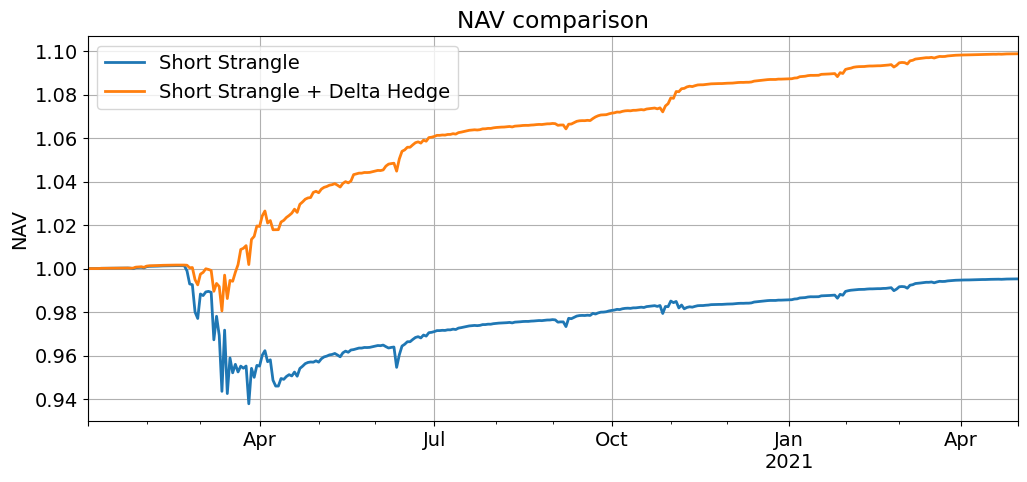

In [4]:
# Comparaison des trajectoires de NAV
fig, ax = plt.subplots(figsize=(12, 5))

bt_unhedged.nav["NAV"].plot(ax=ax, label="Short Strangle", lw=2)
bt_delta_hedged.nav["NAV"].plot(ax=ax, label="Short Strangle + Delta Hedge", lw=2)

ax.set_title("NAV comparison")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()

### Analyse des trajectoires de NAV

La comparaison des courbes de NAV met en évidence une différence claire entre les deux stratégies. La stratégie **non hedgée** subit une baisse marquée au début de la période, liée aux mouvements directionnels importants du marché en 2020. Cette perte initiale n'est que partiellement récupérée par la suite.

La stratégie **delta-hedgée**, en revanche, présente une trajectoire nettement plus régulière. La suppression de l'exposition directionnelle permet de limiter les drawdowns et de stabiliser l'évolution de la NAV. Sur l'ensemble de la période, la stratégie conserve une pente positive et atteint une performance cumulée significativement supérieure.

### Décomposition du P&L

On examine maintenant la décomposition du P&L afin d'isoler la contribution directionnelle.  
Pour chaque stratégie, on compare le **P&L total** et le **P&L hors delta**, obtenu en retirant la composante `delta_pnl`.

Si le hedge fonctionne correctement, la différence entre ces deux séries doit être importante dans la stratégie non hedgée, et nettement plus faible dans la stratégie delta-hedgée.

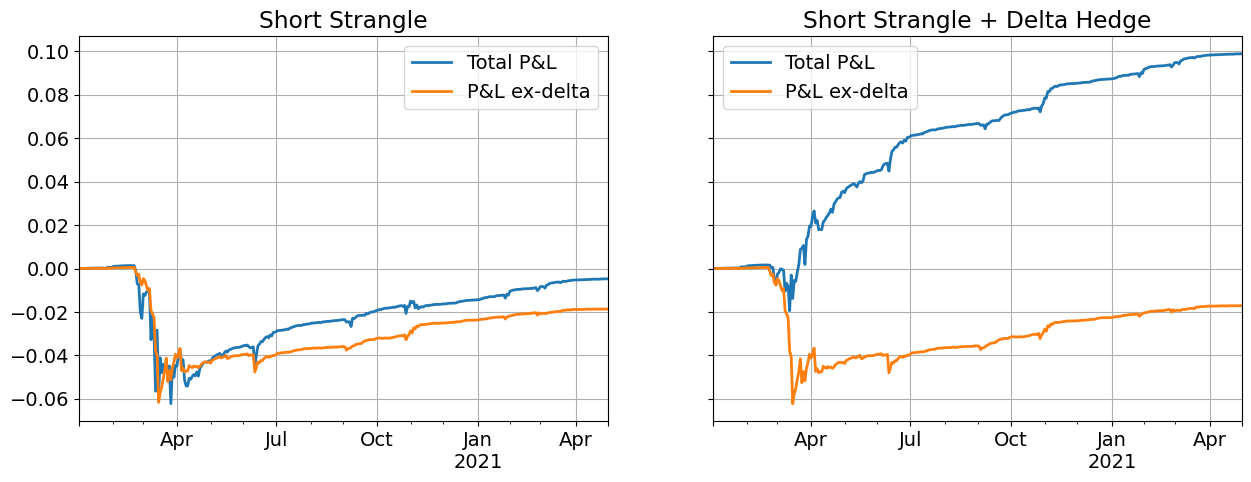

In [5]:
# Comparaison du P&L total et du P&L hors contribution delta
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Stratégie non hedgée
(bt_unhedged.pnl["pnl"]).cumsum().plot(ax=axes[0], label="Total P&L", lw=2)
(bt_unhedged.pnl["pnl"] - bt_unhedged.pnl["delta_pnl"]).cumsum().plot(
    ax=axes[0], label="P&L ex-delta", lw=2
)
axes[0].set_title("Short Strangle")
axes[0].grid(True)
axes[0].legend()

# Stratégie delta-hedgée
(bt_delta_hedged.pnl["pnl"]).cumsum().plot(ax=axes[1], label="Total P&L", lw=2)
(bt_delta_hedged.pnl["pnl"] - bt_delta_hedged.pnl["delta_pnl"]).cumsum().plot(
    ax=axes[1], label="P&L ex-delta", lw=2
)
axes[1].set_title("Short Strangle + Delta Hedge")
axes[1].grid(True)
axes[1].legend()

plt.show()

### Analyse de la décomposition du P&L

Pour la stratégie **non hedgée**, le P&L total et le P&L hors delta sont relativement proches, ce qui indique que la performance provient en grande partie de l'exposition directionnelle au sous-jacent. Les pertes observées lors du choc de marché au début de 2020 reflètent ainsi la sensibilité de la stratégie aux mouvements du spot.

Dans la stratégie **delta-hedgée**, l'écart entre le P&L total et le P&L hors delta devient plus faible, ce qui confirme que la contribution directionnelle est largement neutralisée. Le P&L provient alors principalement des composantes liées aux options (theta et volatilité), ce qui correspond à l'objectif du hedge.

### Exposition delta agrégée du portefeuille

On vérifie enfin que la couverture fonctionne bien en observant l'exposition **delta agrégée** du portefeuille au cours du temps.

Cette mesure est obtenue en sommant les deltas des positions détenues, pondérés par leur poids effectif dans le portefeuille. Une stratégie correctement **delta-hedgée** doit présenter une exposition proche de zéro, alors que la stratégie non hedgée conserve une exposition directionnelle plus importante.

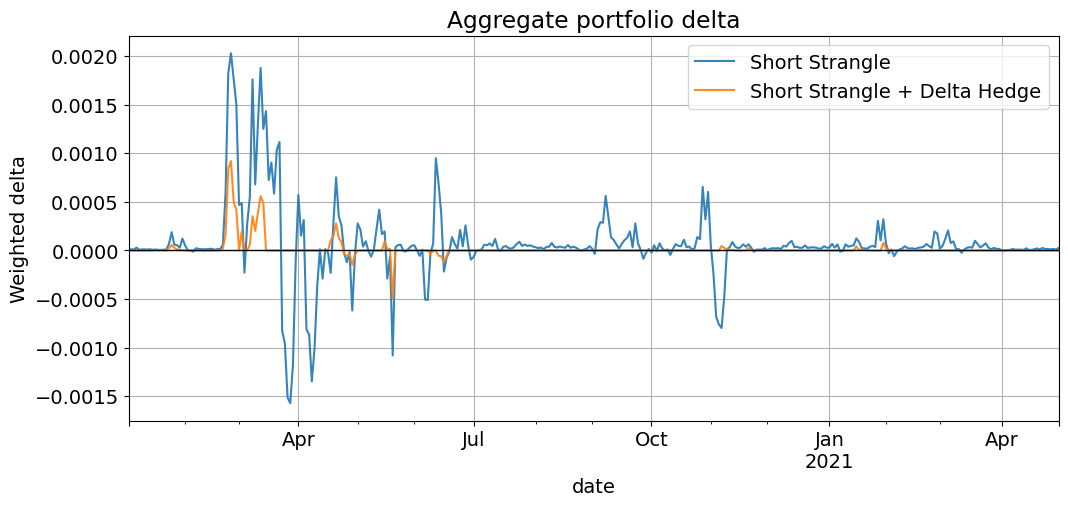

In [6]:
# Calcul de l'exposition delta agrégée
def aggregate_weighted_delta(bt) -> pd.Series:
    df_pos = bt.drifted_positions.copy()
    df_pos["weighted_delta"] = df_pos["delta"] * df_pos["scaled_weight"]
    return df_pos.groupby("date")["weighted_delta"].sum()

delta_exposure_unhedged = aggregate_weighted_delta(bt_unhedged)
delta_exposure_hedged = aggregate_weighted_delta(bt_delta_hedged)

# Comparaison des expositions delta
fig, ax = plt.subplots(figsize=(12, 5))

delta_exposure_unhedged.plot(ax=ax, label="Short Strangle", alpha=0.9)
delta_exposure_hedged.plot(ax=ax, label="Short Strangle + Delta Hedge", alpha=0.9)

ax.axhline(0.0, color="black", lw=1)
ax.set_title("Aggregate portfolio delta")
ax.set_ylabel("Weighted delta")
ax.grid(True)
ax.legend()

plt.show()

### Analyse de l'exposition delta

La stratégie **non hedgée** présente une exposition delta qui fluctue sensiblement autour de zéro. Ces variations reflètent l'exposition directionnelle résiduelle du portefeuille d'options au sous-jacent, notamment lors des mouvements de marché importants.

La stratégie **delta-hedgée** affiche une exposition nettement plus faible et plus stable. Les fluctuations autour de zéro sont fortement atténuées, ce qui confirme que la couverture directionnelle réduit efficacement le risque lié aux mouvements du spot.

### Diagnostic quantitatif de l'exposition delta

Pour compléter l'analyse graphique, on résume l'effet du hedge à l'aide de deux indicateurs simples :

- l'**écart-type de l'exposition delta agrégée**, qui mesure la variabilité de l'exposition directionnelle ;
- la **moyenne absolue de cette exposition**, qui mesure son niveau moyen.

Une couverture delta efficace doit réduire ces deux quantités.

In [7]:
# Indicateurs synthétiques de l'exposition delta
delta_diag = pd.DataFrame(
    {
        "Std of aggregate delta": [
            delta_exposure_unhedged.std(),
            delta_exposure_hedged.std(),
        ],
        "Mean abs aggregate delta": [
            delta_exposure_unhedged.abs().mean(),
            delta_exposure_hedged.abs().mean(),
        ],
    },
    index=["Short Strangle", "Short Strangle + Delta Hedge"],
)

delta_diag.round(6)

,Std of aggregate delta,Mean abs aggregate delta
Short Strangle,0.000385,0.000177
Short Strangle + Delta Hedge,0.000098,0.000022


### Analyse des indicateurs d'exposition delta

Les deux indicateurs confirment l'effet du hedge. La stratégie **non hedgée** présente une variabilité plus importante de l'exposition delta, ainsi qu'un niveau moyen d'exposition directionnelle plus élevé.

Après couverture, ces deux mesures diminuent fortement. L'écart-type de l'exposition delta est divisé par environ quatre, tandis que la moyenne absolue est réduite d'un ordre de grandeur.

Ces résultats confirment que la stratégie **delta-hedgée** maintient une exposition directionnelle nettement plus faible au sous-jacent.

À ce stade, on a validé trois points essentiels :

1. le moteur de backtest produit une NAV et un P\&L cohérents ;
2. la couverture delta réduit effectivement l'exposition directionnelle du portefeuille ;
3. la comparaison entre stratégie nue et stratégie hedgée est suffisamment propre pour servir de base au projet.

Cette étape est importante car les stratégies de variance swap, gamma swap et skew swap reposent ensuite sur le même moteur de sélection, de pondération et de backtest.

### Prise en compte des coûts de transaction

Les résultats précédents valident le fonctionnement général du backtester et du mécanisme de couverture delta. Il est alors naturel d'examiner l'effet des **coûts de transaction**, en particulier pour la stratégie delta-hedgée, qui nécessite des ajustements plus fréquents.

On utilise ici le backtester fondé sur les **bid-ask observés** dans la base de données. On compare à nouveau les deux stratégies à l'aide du tableau de performance et des trajectoires de NAV, afin d'évaluer dans quelle mesure les coûts dégradent les résultats obtenus sans friction.

100%|██████████| 346/346 [00:02<00:00, 150.07it/s]


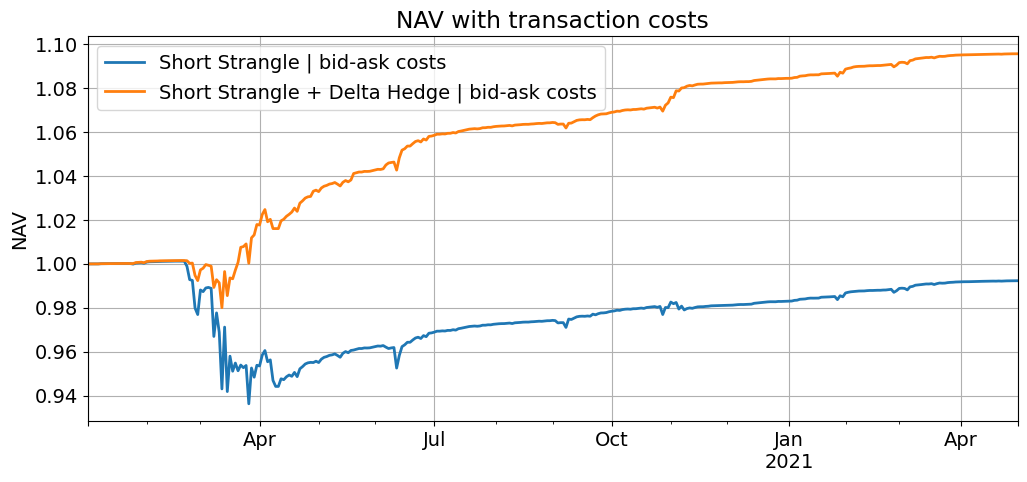

In [8]:
# Backtests avec coûts de transaction observés
bt_unhedged_tcost = BacktesterBidAskFromData(df_trades_unhedged).compute_backtest()
bt_delta_hedged_tcost = BacktesterBidAskFromData(df_trades_delta_hedged).compute_backtest()

# Synthèse des performances avec coûts
summary_tcost_df = performance_summary(
    {
        "Short Strangle": bt_unhedged_tcost,
        "Short Strangle + Delta Hedge": bt_delta_hedged_tcost,
    }
)

summary_tcost_df.round(4)

# Comparaison des NAV avec coûts
fig, ax = plt.subplots(figsize=(12, 5))

bt_unhedged_tcost.nav["NAV"].plot(ax=ax, label="Short Strangle | bid-ask costs", lw=2)
bt_delta_hedged_tcost.nav["NAV"].plot(
    ax=ax,
    label="Short Strangle + Delta Hedge | bid-ask costs",
    lw=2,
)

ax.set_title("NAV with transaction costs")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()

### Analyse de l'effet des coûts de transaction

L'introduction des coûts de transaction réduit légèrement la performance des deux stratégies, mais l'impact reste modéré sur la période étudiée. La trajectoire générale des NAV reste très proche de celle observée sans coûts.

La stratégie **delta-hedgée** conserve une performance supérieure et une trajectoire plus régulière que la stratégie non hedgée. Malgré des ajustements plus fréquents liés au hedge, les coûts de transaction ne suffisent pas à annuler l'amélioration du profil rendement/risque observée précédemment.

# 2. Réplication d'un variance swap, d'un gamma swap et construction d'un skew swap

La librairie fournie contient une implémentation de référence de la réplication discrète d'un **variance swap** à partir d'un strip d'options OTM. Dans ce projet, on reconstruit toutefois explicitement cette réplication afin de contrôler la sélection des options, la pondération des strikes et la cohérence avec les autres swaps étudiés.

Cette approche permet ensuite d'étendre naturellement la construction à deux expositions supplémentaires :

- un **gamma swap**, obtenu à partir d'un strip d'options OTM avec une pondération différente ;
- un **skew swap**, approché comme la différence entre un variance swap et un gamma swap.

Cette construction s'inscrit dans la littérature (Lee) sur les **moment swaps**, où l'on montre qu'une approximation pratique du skew swap peut être obtenue via :

\[
\text{Skew Swap} \approx \text{Variance Swap} - \text{Gamma Swap}.
\]

La réplication repose sur une intégrale en strike qui est discrétisée sur la grille d'options disponible. La construction tient compte :

- de la séparation des options OTM autour du **forward** ;
- de la maturité effective \(T\) ;
- du facteur d'actualisation \(e^{rT}\) ;
- de la pondération en fonction du **strike** dans la formule de réplication.

Cette méthodologie est utilisée de manière cohérente pour construire successivement le **variance swap**, le **gamma swap**, puis le **skew swap**.

### Chargement des données enrichies

La réplication des swaps nécessite plus que la simple chaîne d'options. On a besoin, pour chaque date, du **forward** et du **taux sans risque** afin d'appliquer correctement les formules de réplication statique.

La fonction ci-dessous centralise ce prétraitement et fournit une base homogène pour la construction des strips de variance et de gamma swap.

In [9]:
def load_option_data_with_forward(start_date, end_date, ticker="SPY"):
    """
    Charge la base d'options et ajoute le forward et le taux sans risque.
    """
    df_options = OptionLoader.load_data(
        start_date,
        end_date,
        process_kwargs={"ticker": ticker},
    ).copy()

    df_rates = USRatesLoader.load_data(start_date, end_date)
    df_options = compute_forward(df_options=df_options, df_rates=df_rates)

    df_options["date"] = pd.to_datetime(df_options["date"])
    return df_options

### Sélection du strip d'options OTM

La réplication discrète repose sur un **strip d'options OTM** construit autour du forward. On sélectionne d'abord la maturité la plus proche de la cible, puis on conserve :

- les **puts OTM** pour les strikes inférieurs au forward ;
- les **calls OTM** pour les strikes supérieurs au forward.

Cette étape est commune à la réplication du variance swap et du gamma swap.

In [10]:
def build_otm_strip_forward_based(df_day, day_to_expiry_target=30):
    """
    Sélectionne la maturité la plus proche de la cible, puis conserve
    les puts OTM (K <= F) et les calls OTM (K >= F).
    """
    selected = select_closest_maturity(
        df_day,
        day_to_expiry_target=day_to_expiry_target,
    ).copy()

    forward = selected["forward"].iloc[0]

    otm_filter = (
        ((selected["call_put"] == "P") & (selected["strike"] <= forward))
        | ((selected["call_put"] == "C") & (selected["strike"] >= forward))
    )

    selected = selected.loc[otm_filter].copy()
    selected = selected.sort_values("strike")
    return selected

### Discrétisation de l'intégrale en strike

Les formules théoriques de réplication sont écrites sous forme d'intégrales continues en strike. En pratique, la base ne contient qu'une **grille finie de strikes**. Il faut donc remplacer l'intégrale par une somme discrète.

La fonction suivante calcule l'écart local `dK` associé à chaque strike. Cette quantité entre directement dans les pondérations des strips.

In [11]:
def add_discrete_dk(df_strip):
    """
    Approxime dK sur une grille discrète de strikes.
    """
    df_strip = df_strip.sort_values("strike").copy()

    prev_k = df_strip["strike"].shift(1)
    next_k = df_strip["strike"].shift(-1)

    dk_center = (next_k - prev_k) / 2.0
    dk_forward = next_k - df_strip["strike"]
    dk_backward = df_strip["strike"] - prev_k

    df_strip["dK"] = dk_center
    df_strip.loc[df_strip["dK"].isna(), "dK"] = dk_forward
    df_strip.loc[df_strip["dK"].isna(), "dK"] = dk_backward

    return df_strip

### Construction des poids du gamma swap

On applique ici la formule discrète de réplication du **gamma swap**, avec une pondération en \(1/K\). La construction tient compte :

- du spot ;
- du taux sans risque ;
- de la maturité effective ;
- de la discrétisation `dK`.

Les poids sont ensuite normalisés par la prime du portefeuille afin d'obtenir une taille de trade exploitable dans le backtester.

In [12]:
def build_gamma_swap_weights_for_date(df_day, day_to_expiry_target=30, weight_sign=-1.0):
    """
    Construit les poids du strip de gamma swap pour une date donnée :
        2 * exp(rT) / (T * S0) * dK / K
    """
    strip_df = build_otm_strip_forward_based(
        df_day=df_day,
        day_to_expiry_target=day_to_expiry_target,
    )
    strip_df = add_discrete_dk(strip_df)

    spot = strip_df["spot"].iloc[0]
    r = strip_df["risk_free_rate"].iloc[0]
    T = strip_df["day_to_expiration"].iloc[0] / 365.25

    strip_df["raw_weight"] = (
        weight_sign
        * 2.0
        * np.exp(r * T)
        / (T * spot)
        * strip_df["dK"]
        / strip_df["strike"]
    )

    strip_df["mid"] = (strip_df["bid"] + strip_df["ask"]) / 2
    premium = (strip_df["raw_weight"] * strip_df["mid"]).sum()

    strip_df["weight"] = strip_df["raw_weight"] / abs(premium)
    strip_df["trade_type"] = "GammaSwapCustom"
    strip_df["leg_name"] = "Gamma Swap OTM strip"
    strip_df["entry_date"] = strip_df["date"]

    return strip_df

### Génération de la série de trades du gamma swap

La dernière étape consiste à répéter cette construction à chaque date de rebalancement. On obtient ainsi une **série temporelle de portefeuilles gamma swap**, directement compatible avec le backtester.

Cette fonction constitue l'interface principale entre la réplication théorique et l'analyse de performance.

In [13]:
def generate_gamma_swap_trades(
    start_date,
    end_date,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
):
    """
    Génère les trades du gamma swap sur l'ensemble de la période.
    """
    df_options = load_option_data_with_forward(start_date, end_date, ticker=ticker)

    rebal_dates = sorted(
        df_options.loc[df_options["date"].dt.weekday == rebal_week_day, "date"].unique()
    )

    trades = []

    for dt in rebal_dates:
        df_day = df_options.loc[df_options["date"] == dt].copy()
        if df_day.empty:
            continue

        try:
            gamma_df = build_gamma_swap_weights_for_date(
                df_day=df_day,
                day_to_expiry_target=day_to_expiry_target,
                weight_sign=weight_sign,
            )
            trades.append(gamma_df)
        except Exception:
            continue

    if not trades:
        raise ValueError("Aucun trade gamma swap n'a pu être généré.")

    return pd.concat(trades, ignore_index=True)

### Vérification de la construction du gamma swap sur une date

Avant de lancer le backtest complet, on vérifie la construction du strip de **gamma swap** sur une date donnée. Cette étape permet d'inspecter les strikes retenus, la séparation entre puts et calls OTM, ainsi que les poids obtenus après discrétisation.

Il s'agit d'un contrôle de cohérence local sur une journée, avant de généraliser la construction à l'ensemble de la période.

In [14]:
# Chargement des données enrichies en forward sur la période d'étude
START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2022, 4, 30)

df_options_fw = load_option_data_with_forward(START_DATE, END_DATE, ticker="SPY")

# Exemple de construction du gamma swap sur une date donnée
one_day = df_options_fw.loc[df_options_fw["date"] == pd.Timestamp("2020-01-08")].copy()

gamma_one_day = build_gamma_swap_weights_for_date(
    df_day=one_day,
    day_to_expiry_target=30,
    weight_sign=-1.0,
)

gamma_one_day[["strike", "call_put", "spot", "forward", "dK", "weight"]].head(20)

,strike,call_put,spot,forward,dK,weight
72,270.0,P,324.39,324.789905,5.00,-0.077411
73,275.0,P,324.39,324.789905,5.00,-0.076004
74,280.0,P,324.39,324.789905,3.75,-0.055985
75,282.5,P,324.39,324.789905,2.50,-0.036993
76,285.0,P,324.39,324.789905,2.50,-0.036669
77,287.5,P,324.39,324.789905,2.50,-0.036350
78,290.0,P,324.39,324.789905,2.50,-0.036036
79,292.5,P,324.39,324.789905,2.50,-0.035728
80,295.0,P,324.39,324.789905,2.50,-0.035426
81,297.5,P,324.39,324.789905,2.50,-0.035128


### Vérification locale des poids du gamma swap

Avant le backtest complet, on contrôle les poids du strip sur une date donnée. Cette vérification permet de s'assurer que la séparation entre puts et calls OTM est correcte autour du forward, et que la pondération décroît avec le strike selon la formule retenue.

On peut ainsi valider localement la construction du portefeuille avant de la généraliser à l'ensemble de la période.

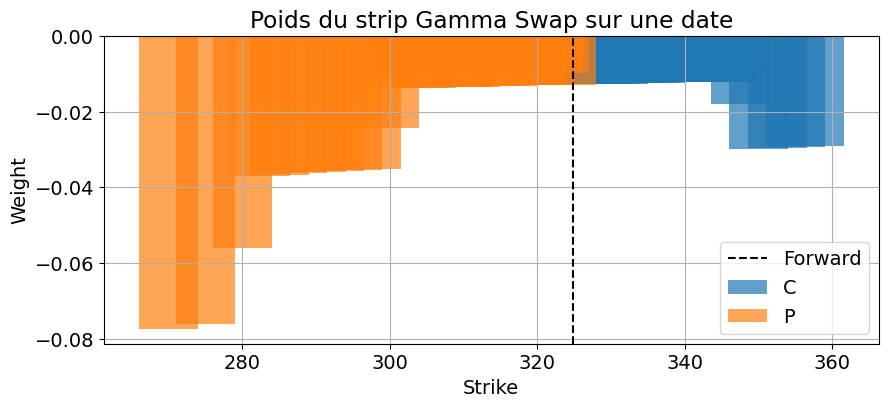

In [15]:
# Visualisation des poids du strip sur une date
fig, ax = plt.subplots(figsize=(10, 4))

for cp, g in gamma_one_day.groupby("call_put"):
    ax.bar(
        g["strike"],
        g["weight"],
        width=8,
        alpha=0.7,
        label=f"{cp}",
    )

ax.axvline(
    gamma_one_day["forward"].iloc[0],
    color="black",
    linestyle="--",
    label="Forward",
)

ax.set_title("Poids du strip Gamma Swap sur une date")
ax.set_xlabel("Strike")
ax.set_ylabel("Weight")
ax.grid(True)
ax.legend()

plt.show()

### Analyse des poids du strip de gamma swap

La figure montre la structure des poids du strip d'options utilisé pour répliquer le gamma swap. Les **puts OTM** apparaissent pour les strikes inférieurs au forward, tandis que les **calls OTM** sont sélectionnés pour les strikes supérieurs, ce qui confirme que la séparation autour du forward est correctement appliquée.

Les poids décroissent en valeur absolue à mesure que le strike s'éloigne du forward, conformément à la pondération en \(1/K\) issue de la formule de réplication. La contribution la plus importante provient des strikes proches du forward, qui concentrent l'essentiel de l'exposition du portefeuille.

### Vérification de la génération des trades gamma swap

Après la validation locale des poids, on applique la construction à l'ensemble des dates de rebalancement. Avant de passer à l'analyse comparative, on vérifie simplement que les trades ont bien été générés tout au long de la période.

Le graphique ci-dessous reporte le nombre de lignes du strip construites à chaque date de rebalancement.

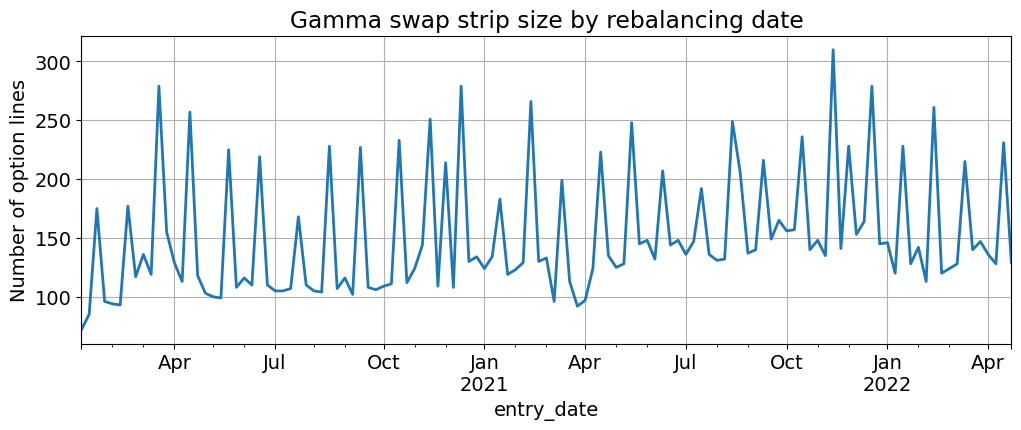

In [18]:
# Génération des trades gamma swap sur toute la période
gamma_trades_fw = generate_gamma_swap_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

# Vérification simple : nombre de lignes générées par date
gamma_trade_count = gamma_trades_fw.groupby("entry_date").size()

fig, ax = plt.subplots(figsize=(12, 4))

gamma_trade_count.plot(ax=ax, lw=2)
ax.set_title("Gamma swap strip size by rebalancing date")
ax.set_ylabel("Number of option lines")
ax.grid(True)

plt.show()

### Réplication homogène du variance swap et du gamma swap

Pour comparer correctement les deux expositions, on reconstruit ici le **variance swap** avec la même méthodologie que pour le gamma swap : même sélection d'options OTM, même discrétisation en strike, même logique de normalisation et même fréquence de rebalancement.

La seule différence entre les deux portefeuilles provient alors de la **pondération en strike** dans la formule de réplication. Cette construction homogène permet une comparaison plus propre des performances des deux stratégies.

100%|██████████| 121/121 [00:01<00:00, 94.64it/s] 


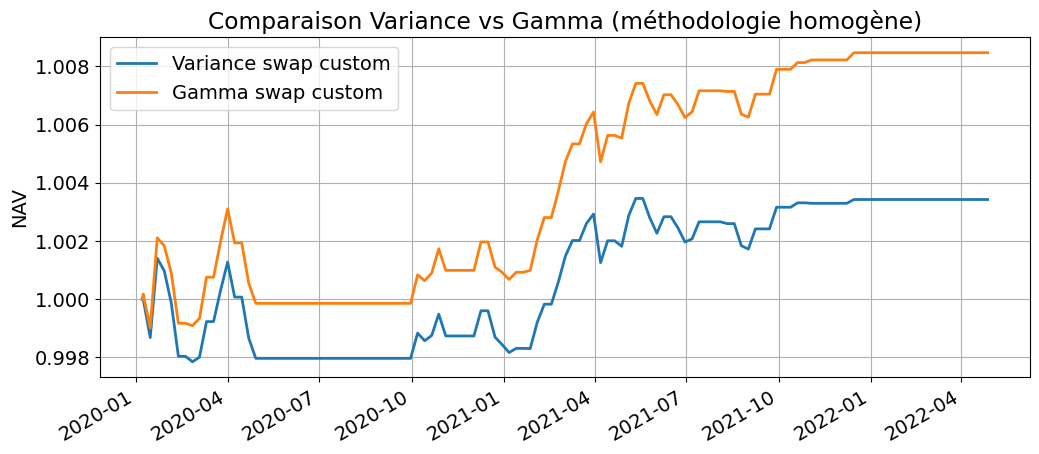

In [19]:
# Construction des poids du variance swap sur une date
def build_variance_swap_weights_for_date(df_day, day_to_expiry_target=30, weight_sign=-1.0):
    """
    Construit les poids du strip de variance swap pour une date donnée :
        2 * exp(rT) / T * dK / K^2
    """
    strip_df = build_otm_strip_forward_based(
        df_day=df_day,
        day_to_expiry_target=day_to_expiry_target,
    )
    strip_df = add_discrete_dk(strip_df)

    r = strip_df["risk_free_rate"].iloc[0]
    T = strip_df["day_to_expiration"].iloc[0] / 365.25

    strip_df["raw_weight"] = (
        weight_sign
        * 2.0
        * np.exp(r * T)
        / T
        * strip_df["dK"]
        / (strip_df["strike"] ** 2)
    )

    # Normalisation par la prime du portefeuille
    strip_df["mid"] = (strip_df["bid"] + strip_df["ask"]) / 2
    premium = (strip_df["raw_weight"] * strip_df["mid"]).sum()

    strip_df["weight"] = strip_df["raw_weight"] / abs(premium)
    strip_df["trade_type"] = "VarianceSwapCustom"
    strip_df["leg_name"] = "Variance Swap OTM strip"
    strip_df["entry_date"] = strip_df["date"]

    return strip_df


# Génération des trades variance swap sur l'ensemble de la période
def generate_variance_swap_trades_custom(
    start_date,
    end_date,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
):
    df_options = load_option_data_with_forward(start_date, end_date, ticker=ticker)

    rebal_dates = sorted(
        df_options.loc[df_options["date"].dt.weekday == rebal_week_day, "date"].unique()
    )

    trades = []

    for dt in rebal_dates:
        df_day = df_options.loc[df_options["date"] == dt].copy()
        if df_day.empty:
            continue

        try:
            var_df = build_variance_swap_weights_for_date(
                df_day=df_day,
                day_to_expiry_target=day_to_expiry_target,
                weight_sign=weight_sign,
            )
            trades.append(var_df)
        except Exception:
            continue

    if not trades:
        raise ValueError("Aucun trade variance swap custom n'a pu être généré.")

    return pd.concat(trades, ignore_index=True)


# Génération des trades variance et gamma swap avec une méthodologie homogène
variance_trades_custom = generate_variance_swap_trades_custom(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

gamma_trades_custom = generate_gamma_swap_trades(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

# Backtest des deux portefeuilles
bt_variance_custom = StrategyBacktester(variance_trades_custom).compute_backtest()
bt_gamma_custom = StrategyBacktester(gamma_trades_custom).compute_backtest()

# Comparaison des trajectoires de NAV
fig, ax = plt.subplots(figsize=(12, 5))

bt_variance_custom.nav["NAV"].plot(ax=ax, label="Variance swap custom", lw=2)
bt_gamma_custom.nav["NAV"].plot(ax=ax, label="Gamma swap custom", lw=2)

ax.set_title("Comparaison Variance vs Gamma (méthodologie homogène)")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()

### Analyse de la comparaison variance vs gamma

Les deux stratégies présentent des trajectoires de NAV proches, ce qui est cohérent avec le fait qu'elles reposent sur le même strip d'options OTM et ne diffèrent que par leur pondération en strike. La stratégie **gamma swap** affiche toutefois une performance légèrement supérieure sur la période.

Ce résultat suggère que la pondération en \(1/K\) du gamma swap conduit ici à une exposition plus favorable que la pondération en \(1/K^2\) du variance swap. L'écart reste modéré, ce qui confirme que les deux portefeuilles capturent des expositions voisines mais non identiques.

### Analyse comparative des réplications variance et gamma

La comparaison précédente repose sur deux portefeuilles construits avec une méthodologie homogène : même univers d'options OTM, même discrétisation en strike, même fréquence de rebalancement et même logique de normalisation.

Dans ce cadre, la différence entre les deux stratégies provient uniquement de la **pondération en strike** utilisée dans la formule de réplication. Cette homogénéité est importante, car elle permet d'interpréter les écarts de performance comme un effet propre à l'exposition **variance** versus **gamma**, et non comme une conséquence d'un traitement de données ou d'une implémentation différente.

## Construction du skew swap

Dans la littérature sur les moment swaps, le **skew swap** peut être approché comme la différence entre un **variance swap** et un **gamma swap**.

On construit donc ici un portefeuille de skew swap en combinant directement les deux réplications précédentes. Cette approche permet d'obtenir une exposition empirique à l'asymétrie de la distribution des rendements à partir du même univers d'options vanilles.

In [20]:
# Construction du skew swap comme différence entre variance et gamma
def build_skew_swap_trades_custom(variance_trades_df, gamma_trades_df):
    var_df = variance_trades_df.copy()
    gam_df = gamma_trades_df.copy()

    gam_df["weight"] = -gam_df["weight"]

    common_cols = sorted(set(var_df.columns).intersection(set(gam_df.columns)))
    return pd.concat([var_df[common_cols], gam_df[common_cols]], ignore_index=True)


skew_trades_custom = build_skew_swap_trades_custom(
    variance_trades_custom,
    gamma_trades_custom,
)

bt_skew_custom = StrategyBacktester(skew_trades_custom).compute_backtest()

100%|██████████| 121/121 [00:00<00:00, 130.28it/s]


### Comparaison des performances des swaps

On compare maintenant les performances des trois portefeuilles construits précédemment : **variance swap**, **gamma swap** et **skew swap**.

Les trois stratégies reposent sur la même sélection d'options et la même fréquence de rebalancement. Les différences observées proviennent donc uniquement de la pondération utilisée dans la réplication.

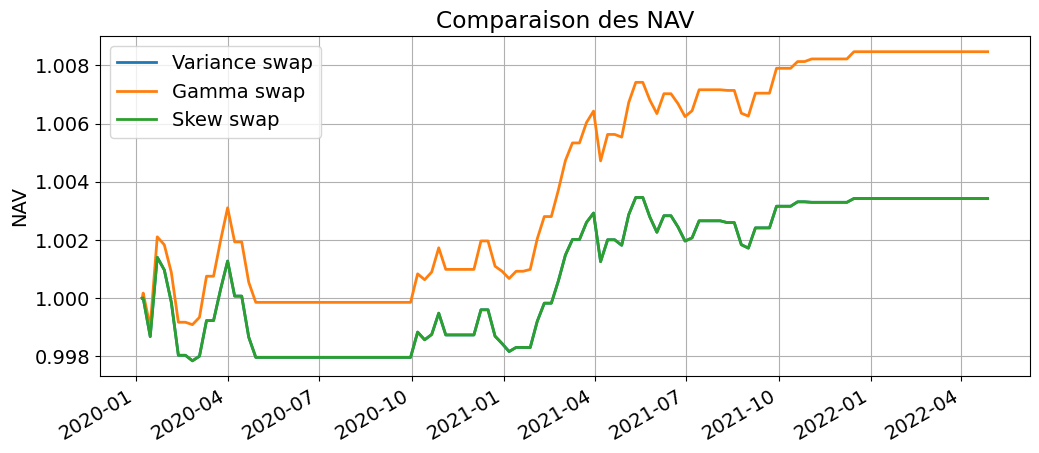

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

bt_variance_custom.nav["NAV"].plot(ax=ax, label="Variance swap", lw=2)
bt_gamma_custom.nav["NAV"].plot(ax=ax, label="Gamma swap", lw=2)
bt_skew_custom.nav["NAV"].plot(ax=ax, label="Skew swap", lw=2)

ax.set_title("Comparaison des NAV")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()

### Analyse de la comparaison des swaps

Les trois stratégies présentent des trajectoires de NAV très proches. Cela s'explique par le fait que les portefeuilles reposent sur le même strip d'options OTM et ne diffèrent que par la pondération en strike utilisée dans la réplication.

Le gamma swap affiche une performance légèrement supérieure sur la période, tandis que le variance swap et le skew swap restent proches. Cette proximité confirme que les deux réplications capturent des expositions similaires à la volatilité implicite, avec seulement une différence dans la sensibilité relative aux strikes.

### Synthèse des performances

On résume ensuite les performances des trois stratégies à l'aide des métriques utilisées précédemment : rendement moyen, volatilité, Sharpe ratio et drawdown.

In [25]:
def compute_perf(bt):
    nav = bt.nav["NAV"]
    rets = nav.pct_change().dropna()

    return {
        "Final NAV": nav.iloc[-1],
        "Sharpe": sharpe_ratio(rets),
        "Max Drawdown (%)": 100 * max_drawdown(rets),
        "Calmar": calmar_ratio(rets),
        "Mean Daily Return": rets.mean(),
        "Daily Vol": rets.std(),
    }

perf_swaps_df = pd.DataFrame({
    "Variance swap": compute_perf(bt_variance_custom),
    "Gamma swap": compute_perf(bt_gamma_custom),
    "Skew swap": compute_perf(bt_skew_custom),
}).T

perf_swaps_df.round(4)
    

,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean Daily Return,Daily Vol
Variance swap,1.0034,0.8155,-0.3556,2.0144,0.0000,0.0006
Gamma swap,1.0085,1.8937,-0.3241,5.4353,0.0001,0.0006
Skew swap,1.0034,0.8155,-0.3556,2.0144,0.0000,0.0006


### Analyse des performances des swaps

Le variance swap et le skew swap présentent des performances presque identiques sur la période étudiée. Ce résultat s'explique par la forte proximité entre les portefeuilles variance et gamma construits sur le même strip d'options OTM.

Comme le skew swap est défini comme la différence entre ces deux portefeuilles, l'exposition obtenue reste faible et produit une trajectoire de NAV proche de celle du variance swap.

Dans la section suivante, on construit une seconde version du skew swap en utilisant un strip d'options plus éloigné du forward afin de renforcer l'exposition à l'asymétrie de la surface de volatilité.

### Variante : construction d'un skew swap par pondération directe du troisième moment

La construction précédente du skew swap comme différence entre un **variance swap** et un **gamma swap** produit une exposition relativement faible, car les deux portefeuilles restent proches sur le même strip d'options OTM.

On construit donc ici une version plus directe, fondée sur une pondération en \(1/K^3\). Cette approche vise à rapprocher davantage le portefeuille d'une exposition au **troisième moment implicite**, tout en conservant la même méthodologie générale : sélection des options OTM, discrétisation en strike, normalisation par la prime et backtest sur la même période.

On compare ensuite cette nouvelle construction :
- au **variance swap** ;
- au **gamma swap** ;
- à l'ancien **skew swap** défini comme `variance - gamma`.

Enfin, on mesure la corrélation entre les rendements de ces portefeuilles et le **troisième moment réalisé** du sous-jacent.

100%|██████████| 121/121 [00:00<00:00, 135.94it/s]


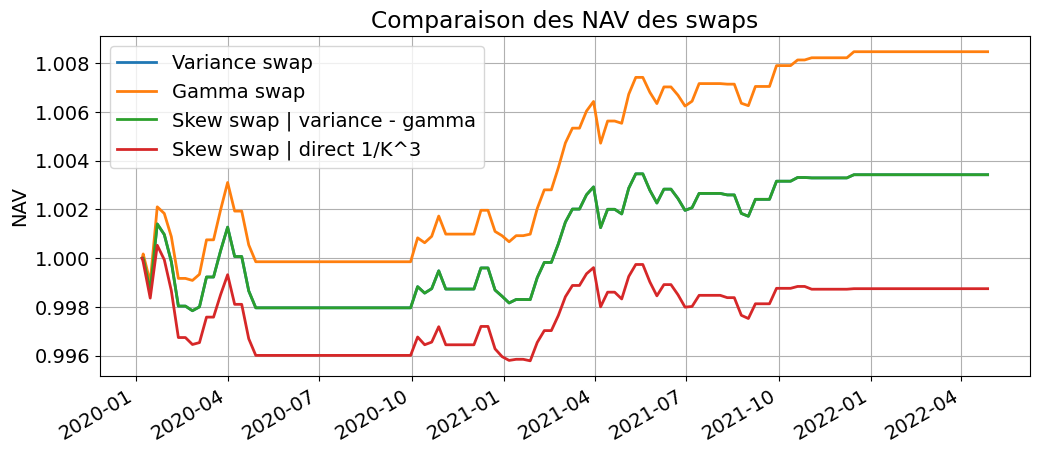

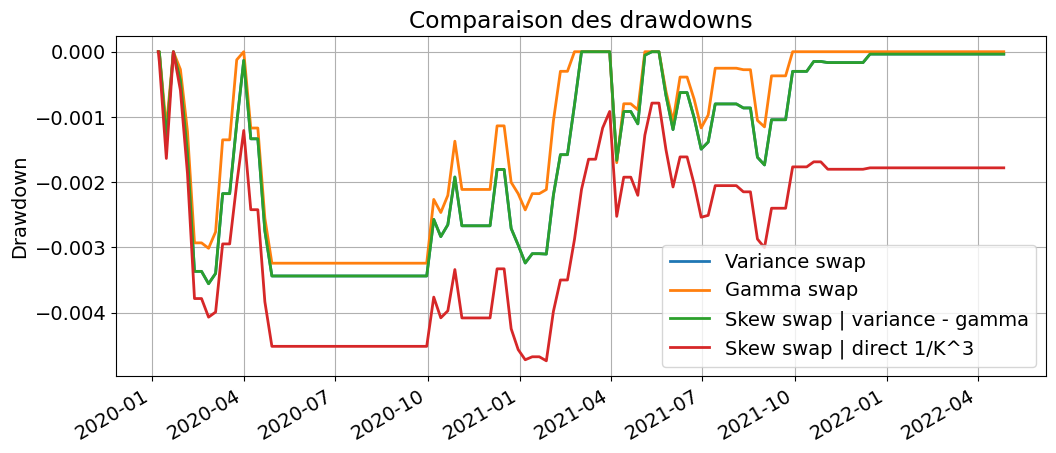

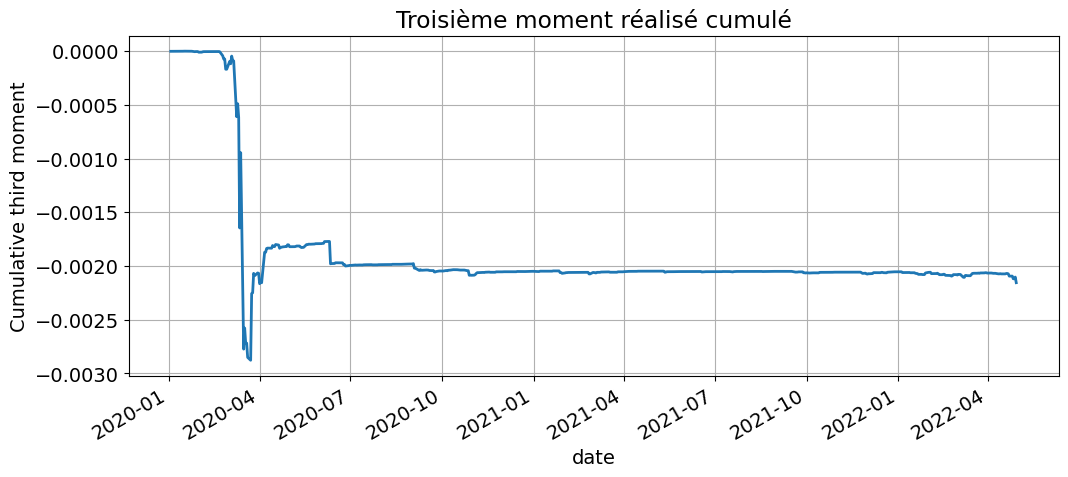

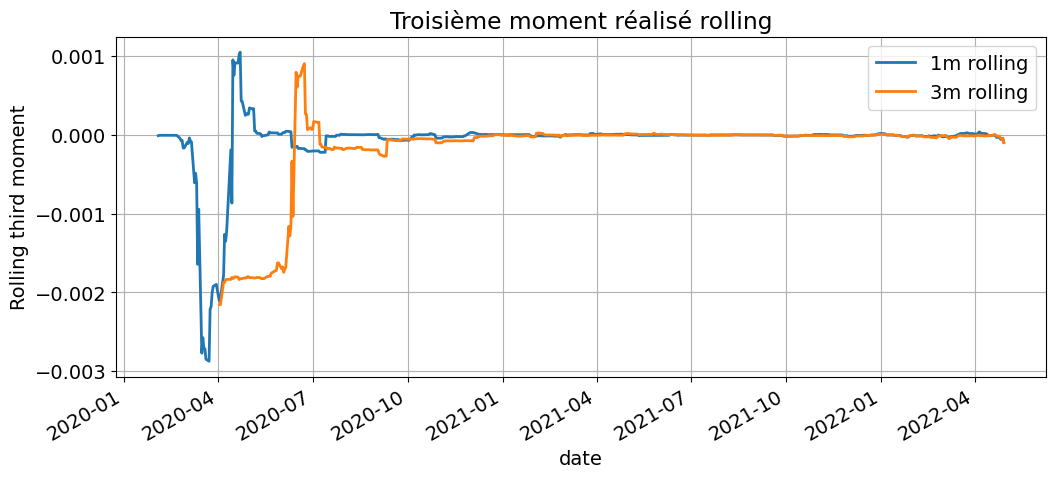

,variance_swap_return,gamma_swap_return,skew_swap_old_return,skew_swap_direct_return,third_moment_daily,third_moment_1m_change,third_moment_3m_change
variance_swap_return,1.000000,0.996184,1.000000,0.995571,-0.347966,0.000215,-0.041478
gamma_swap_return,0.996184,1.000000,0.996184,0.984118,-0.339184,-0.005233,-0.033963
skew_swap_old_return,1.000000,0.996184,1.000000,0.995571,-0.347966,0.000215,-0.041478
skew_swap_direct_return,0.995571,0.984118,0.995571,1.000000,-0.355453,0.005516,-0.048597
third_moment_daily,-0.347966,-0.339184,-0.347966,-0.355453,1.000000,-0.129258,0.284800
third_moment_1m_change,0.000215,-0.005233,0.000215,0.005516,-0.129258,1.000000,0.001947
third_moment_3m_change,-0.041478,-0.033963,-0.041478,-0.048597,0.284800,0.001947,1.000000


In [28]:
# Construction d'un proxy direct de skew swap avec une pondération en 1 / K^3
def build_skew_swap_weights_direct_for_date(
    df_day,
    day_to_expiry_target=30,
    weight_sign=-1.0,
):
    """
    Construit les poids d'un proxy de skew swap à partir d'une pondération
    directe en 1 / K^3 sur le strip OTM.
    """
    strip_df = build_otm_strip_forward_based(
        df_day=df_day,
        day_to_expiry_target=day_to_expiry_target,
    )
    strip_df = add_discrete_dk(strip_df)

    r = strip_df["risk_free_rate"].iloc[0]
    T = strip_df["day_to_expiration"].iloc[0] / 365.25

    strip_df["raw_weight"] = (
        weight_sign
        * 6.0
        * np.exp(r * T)
        / T
        * strip_df["dK"]
        / (strip_df["strike"] ** 3)
    )

    strip_df["mid"] = (strip_df["bid"] + strip_df["ask"]) / 2
    premium = (strip_df["raw_weight"] * strip_df["mid"]).sum()

    strip_df["weight"] = strip_df["raw_weight"] / abs(premium)
    strip_df["trade_type"] = "SkewSwapDirect"
    strip_df["leg_name"] = "Skew Swap direct OTM strip"
    strip_df["entry_date"] = strip_df["date"]

    return strip_df


# Génération des trades de skew swap direct sur l'ensemble de la période
def generate_skew_swap_trades_direct(
    start_date,
    end_date,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
):
    df_options = load_option_data_with_forward(start_date, end_date, ticker=ticker)

    rebal_dates = sorted(
        df_options.loc[df_options["date"].dt.weekday == rebal_week_day, "date"].unique()
    )

    trades = []

    for dt in rebal_dates:
        df_day = df_options.loc[df_options["date"] == dt].copy()
        if df_day.empty:
            continue

        try:
            skew_df = build_skew_swap_weights_direct_for_date(
                df_day=df_day,
                day_to_expiry_target=day_to_expiry_target,
                weight_sign=weight_sign,
            )
            trades.append(skew_df)
        except Exception:
            continue

    if not trades:
        raise ValueError("Aucun trade de skew swap direct n'a pu être généré.")

    return pd.concat(trades, ignore_index=True)


# Construction et backtest du nouveau skew swap
skew_trades_direct = generate_skew_swap_trades_direct(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker="SPY",
    day_to_expiry_target=30,
    rebal_week_day=2,
    weight_sign=-1.0,
)

bt_skew_direct = StrategyBacktester(skew_trades_direct).compute_backtest()


# Comparaison des NAV : variance, gamma, ancien skew et nouveau skew direct
fig, ax = plt.subplots(figsize=(12, 5))

bt_variance_custom.nav["NAV"].plot(ax=ax, label="Variance swap", lw=2)
bt_gamma_custom.nav["NAV"].plot(ax=ax, label="Gamma swap", lw=2)
bt_skew_custom.nav["NAV"].plot(ax=ax, label="Skew swap | variance - gamma", lw=2)
bt_skew_direct.nav["NAV"].plot(ax=ax, label="Skew swap | direct 1/K^3", lw=2)

ax.set_title("Comparaison des NAV des swaps")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()


# Tableau de performance comparatif
perf_swaps_extended_df = pd.DataFrame(
    {
        "Variance swap": compute_perf(bt_variance_custom),
        "Gamma swap": compute_perf(bt_gamma_custom),
        "Skew swap | variance - gamma": compute_perf(bt_skew_custom),
        "Skew swap | direct 1/K^3": compute_perf(bt_skew_direct),
    }
).T

perf_swaps_extended_df.round(4)


# Fonction utilitaire de drawdown si elle n'existe pas déjà dans le notebook
def compute_drawdown(nav_series: pd.Series) -> pd.Series:
    running_max = nav_series.cummax()
    return nav_series / running_max - 1.0


# Comparaison des drawdowns
dd_variance = compute_drawdown(bt_variance_custom.nav["NAV"])
dd_gamma = compute_drawdown(bt_gamma_custom.nav["NAV"])
dd_skew_old = compute_drawdown(bt_skew_custom.nav["NAV"])
dd_skew_direct = compute_drawdown(bt_skew_direct.nav["NAV"])

fig, ax = plt.subplots(figsize=(12, 5))

dd_variance.plot(ax=ax, label="Variance swap", lw=2)
dd_gamma.plot(ax=ax, label="Gamma swap", lw=2)
dd_skew_old.plot(ax=ax, label="Skew swap | variance - gamma", lw=2)
dd_skew_direct.plot(ax=ax, label="Skew swap | direct 1/K^3", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()

plt.show()


# Extraction d'une série spot propre
df_spot = extract_spot_from_options(df_options_fw).copy()
df_spot["date"] = pd.to_datetime(df_spot["date"])
df_spot = df_spot.sort_values("date").drop_duplicates("date")

# Calcul des log-returns et du troisième moment réalisé
df_spot["log_return"] = np.log(df_spot["spot"] / df_spot["spot"].shift(1))
df_spot["third_moment_daily"] = df_spot["log_return"] ** 3
df_spot["third_moment_cum"] = df_spot["third_moment_daily"].cumsum()
df_spot["third_moment_1m"] = df_spot["third_moment_daily"].rolling(21).sum()
df_spot["third_moment_3m"] = df_spot["third_moment_daily"].rolling(63).sum()

# Graphique du troisième moment cumulé
fig, ax = plt.subplots(figsize=(12, 5))

df_spot.set_index("date")["third_moment_cum"].plot(ax=ax, lw=2)

ax.set_title("Troisième moment réalisé cumulé")
ax.set_ylabel("Cumulative third moment")
ax.grid(True)

plt.show()

# Graphique du troisième moment rolling
fig, ax = plt.subplots(figsize=(12, 5))

df_spot.set_index("date")["third_moment_1m"].plot(ax=ax, label="1m rolling", lw=2)
df_spot.set_index("date")["third_moment_3m"].plot(ax=ax, label="3m rolling", lw=2)

ax.set_title("Troisième moment réalisé rolling")
ax.set_ylabel("Rolling third moment")
ax.grid(True)
ax.legend()

plt.show()


# Corrélations entre les rendements des stratégies et le troisième moment réalisé
rets_variance = bt_variance_custom.nav["NAV"].pct_change().dropna()
rets_gamma = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew_old = bt_skew_custom.nav["NAV"].pct_change().dropna()
rets_skew_direct = bt_skew_direct.nav["NAV"].pct_change().dropna()

corr_compare_df = pd.concat(
    [
        rets_variance.rename("variance_swap_return"),
        rets_gamma.rename("gamma_swap_return"),
        rets_skew_old.rename("skew_swap_old_return"),
        rets_skew_direct.rename("skew_swap_direct_return"),
        df_spot.set_index("date")["third_moment_daily"].rename("third_moment_daily"),
        df_spot.set_index("date")["third_moment_1m"].diff().rename("third_moment_1m_change"),
        df_spot.set_index("date")["third_moment_3m"].diff().rename("third_moment_3m_change"),
    ],
    axis=1,
).dropna()

corr_compare_df.corr()

### Comparaison des différentes constructions du skew swap

La comparaison des trajectoires de NAV montre que les portefeuilles variance et gamma restent très proches sur la période étudiée. Le skew swap construit comme la différence entre ces deux portefeuilles présente donc une dynamique très similaire à celle du variance swap.

La version alternative du skew swap fondée sur une pondération directe en \(1/K^3\) introduit une légère différenciation. Cette pondération accentue l'importance des strikes éloignés et se rapproche davantage d'une exposition au troisième moment implicite. La trajectoire de NAV reste toutefois relativement proche de celles des autres stratégies.

Les drawdowns confirment cette observation. Le skew swap direct présente des fluctuations légèrement plus marquées, ce qui est cohérent avec une sensibilité accrue aux options très OTM.

### Corrélation avec le troisième moment réalisé

L'analyse des corrélations montre que les rendements des différents portefeuilles restent fortement corrélés entre eux. Les corrélations entre variance, gamma et skew swaps dépassent 0.98, ce qui indique que ces stratégies capturent essentiellement une exposition commune à la volatilité implicite.

La corrélation avec le troisième moment réalisé est modérée et négative (environ -0.35). Cela suggère que ces portefeuilles réagissent partiellement aux épisodes d'asymétrie des rendements, en particulier lors des phases de stress de marché, mais qu'ils ne constituent pas une réplication pure du troisième moment.

Ces résultats illustrent une difficulté bien connue dans la pratique : les moments d'ordre supérieur sont plus difficiles à isoler à partir d'un simple strip d'options vanilles, même avec des pondérations théoriquement adaptées.

## Extension : moment d'ordre 4 et proxy de kurtosis swap

Pour compléter l'étude des moments réalisés, on ajoute une mesure empirique du **quatrième moment** des log-returns, souvent interprété comme un proxy de **kurtosis swap réalisé**.

On considère ici le payoff discret :

\[
\text{MOMS}^{(4)} = \sum_{i=1}^{n} \left(\log\frac{S_i}{S_{i-1}}\right)^4
\]

L'objectif est d'étendre l'analyse au cas du **moment d'ordre 4** à partir des rendements observés du sous-jacent. Contrairement aux sections précédentes, il ne s'agit pas ici de construire une réplication complète par strip d'options, mais de mesurer directement la composante réalisée du quatrième moment.

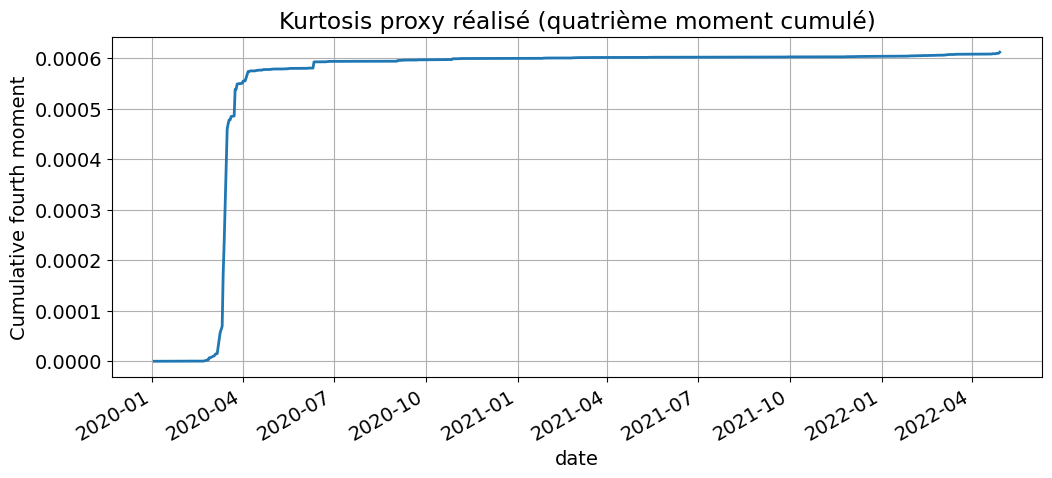

In [30]:
def load_spot_series(start_date, end_date, ticker="SPY"):
    """
    Charge une série spot quotidienne à partir de la base d'options.
    """
    df_options = OptionLoader.load_data(
        start_date,
        end_date,
        process_kwargs={"ticker": ticker},
    ).copy()

    df_spot = extract_spot_from_options(df_options).copy()
    df_spot["date"] = pd.to_datetime(df_spot["date"])
    df_spot = df_spot.sort_values("date").drop_duplicates("date")
    return df_spot


def compute_realized_moment_swap(df_spot, order=4):
    """
    Calcule le moment réalisé d'ordre `order` à partir des log-returns.
    """
    df = df_spot.copy()
    df["log_return"] = np.log(df["spot"] / df["spot"].shift(1))
    df[f"moment_{order}"] = df["log_return"] ** order
    return df


# Construction de la série spot et du quatrième moment réalisé
df_spot = load_spot_series(START_DATE, END_DATE, ticker="SPY")
df_kurtosis = compute_realized_moment_swap(df_spot, order=4)

df_kurtosis[["date", "spot", "log_return", "moment_4"]].head()

# Trajectoire cumulée du quatrième moment
fig, ax = plt.subplots(figsize=(12, 5))

df_kurtosis.set_index("date")["moment_4"].cumsum().plot(ax=ax, lw=2)

ax.set_title("Kurtosis proxy réalisé (quatrième moment cumulé)")
ax.set_ylabel("Cumulative fourth moment")
ax.grid(True)

plt.show()

### Interprétation du quatrième moment réalisé

La trajectoire cumulée du quatrième moment met en évidence l'importance des épisodes de rendements extrêmes dans la dynamique de kurtosis. On observe une contribution dominante au début de la période, correspondant au choc de marché de mars 2020. Les rendements très élevés en valeur absolue durant cette phase génèrent des valeurs importantes de \((\log S_t/S_{t-1})^4\), ce qui explique la forte hausse initiale de la série cumulée.

Après cet épisode, la pente de la courbe devient beaucoup plus faible. Cela reflète un retour à des fluctuations de marché plus modérées, où les contributions au quatrième moment sont nettement plus faibles. La mesure cumulée est donc principalement déterminée par les épisodes extrêmes, ce qui est caractéristique des moments d'ordre élevé.

### Kurtosis réalisé en version rolling

La représentation rolling permet de suivre l'évolution locale du quatrième moment réalisé sur différentes fenêtres temporelles. On considère ici deux horizons :

- une fenêtre de **3 mois (63 jours)** ;
- une fenêtre de **6 mois (126 jours)**.

Contrairement à la version cumulée, ces mesures mettent en évidence les variations plus récentes de la kurtosis réalisée. Les pics observés correspondent aux périodes de forte volatilité et de rendements extrêmes, tandis que les périodes plus calmes se traduisent par des valeurs proches de zéro.

Cette représentation permet donc de mieux caractériser la dynamique temporelle des épisodes de forte asymétrie et de queues épaisses dans la distribution des rendements.

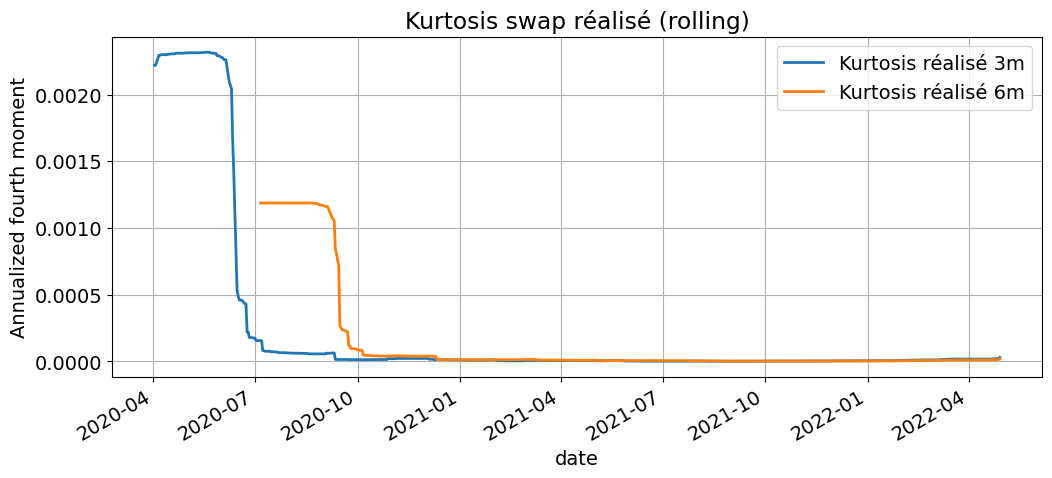

In [ ]:
def compute_rolling_realized_moment(df_spot, order=4, window=63, annualize=True, trading_days=252):
    """
Annualisation par mise à l'échelle trading_days / window,
afin de rendre les moments comparables entre différentes fenêtres.
"""
    df = df_spot.copy()
    df["log_return"] = np.log(df["spot"] / df["spot"].shift(1))
    df[f"moment_{order}"] = df["log_return"] ** order

    rolling = df[f"moment_{order}"].rolling(window).sum()

    if annualize:
        rolling = rolling * (trading_days / window)

    out = pd.DataFrame({
        "date": df["date"],
        f"realized_moment_{order}_{window}d": rolling
    })
    return out

kurt_3m = compute_rolling_realized_moment(df_spot, order=4, window=63)
kurt_6m = compute_rolling_realized_moment(df_spot, order=4, window=126)

fig, ax = plt.subplots(figsize=(12, 5))

kurt_3m.set_index("date").iloc[:, 0].plot(ax=ax, label="Kurtosis réalisé 3m", lw=2)
kurt_6m.set_index("date").iloc[:, 0].plot(ax=ax, label="Kurtosis réalisé 6m", lw=2)

ax.set_title("Kurtosis swap réalisé (rolling)")
ax.set_ylabel("Annualized fourth moment")
ax.grid(True)
ax.legend()
plt.show()

### Comparaison entre kurtosis réalisée et volatilité réalisée

La mesure rolling du quatrième moment met en évidence une forte concentration de la kurtosis réalisée au début de la période, en particulier autour du choc de marché de 2020. Les fenêtres à 3 mois et 6 mois confirment que cette mesure est dominée par quelques épisodes extrêmes, puis retombe rapidement vers des niveaux très faibles.

Il est alors naturel de comparer cette dynamique à celle de la **volatilité réalisée**. Les deux quantités augmentent lors des phases de stress, mais la kurtosis est beaucoup plus sensible aux observations extrêmes. Cette comparaison permet de distinguer un simple régime de forte volatilité d'un régime où les queues de distribution deviennent particulièrement épaisses.

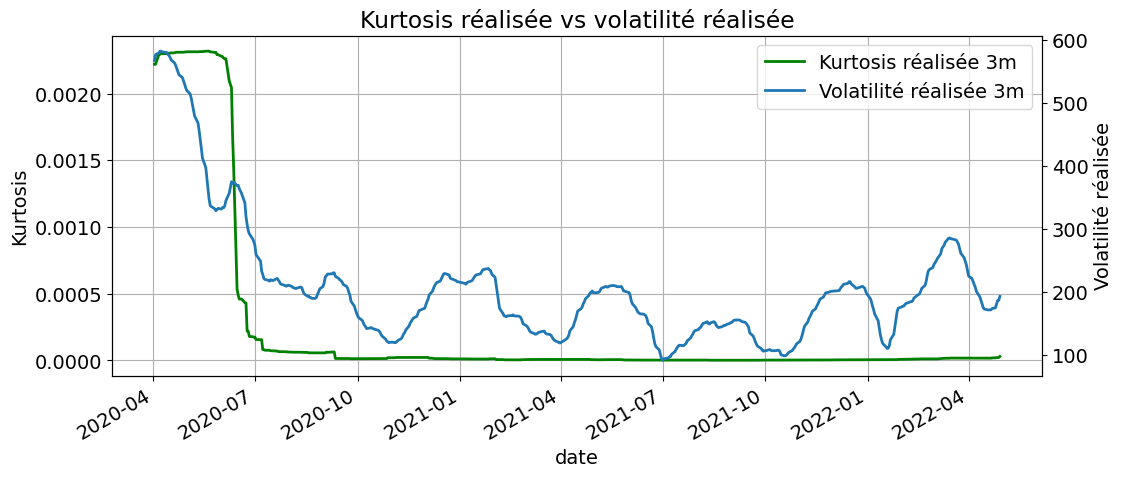

In [32]:
df_spot_k = df_spot.copy()
df_spot_k["date"] = pd.to_datetime(df_spot_k["date"])

# Volatilité réalisée rolling sur 3 mois
rv_3m = rolling_realized_volatility(
    df_spot_k.set_index("date")["spot"],
    window=63,
    volatility_type="std",
).rename("realized_vol_3m")

# Comparaison entre kurtosis réalisée et volatilité réalisée
compare_df = pd.concat(
    [
        kurt_3m.set_index("date").iloc[:, 0],
        rv_3m,
    ],
    axis=1,
).dropna()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

compare_df.iloc[:, 0].plot(ax=ax1, label="Kurtosis réalisée 3m", lw=2, color="green")
compare_df.iloc[:, 1].plot(ax=ax2, label="Volatilité réalisée 3m", lw=2)

ax1.set_title("Kurtosis réalisée vs volatilité réalisée")
ax1.set_ylabel("Kurtosis")
ax2.set_ylabel("Volatilité réalisée")
ax1.grid(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

### Dynamique de la kurtosis réalisée

La comparaison entre kurtosis réalisée et volatilité réalisée montre que ces deux mesures réagissent fortement lors des épisodes de stress de marché. Le pic observé au début de la période correspond au choc de marché de 2020, durant lequel les rendements extrêmes ont fortement contribué au quatrième moment réalisé.

Après cet épisode, la kurtosis retombe rapidement vers des niveaux très faibles. Contrairement à la volatilité réalisée, qui continue de fluctuer au fil du temps, la kurtosis apparaît beaucoup plus concentrée autour des périodes de rendements extrêmes. Cette propriété est typique des moments d'ordre élevé, qui sont dominés par un petit nombre d'observations très éloignées de la moyenne.

### Corrélation entre les swaps et les variations de kurtosis

On compare enfin les rendements des portefeuilles de volatilité aux variations de la kurtosis réalisée. L'objectif est de vérifier si les stratégies construites à partir d'options capturent, même partiellement, les changements du quatrième moment réalisé.

Comme la version directe du skew swap en \(1/K^3\) est plus proche d'une exposition au troisième moment que l'ancienne construction `variance - gamma`, il est préférable de l'utiliser ici dans l'analyse finale. On conserve néanmoins variance et gamma pour situer cette exposition par rapport aux autres portefeuilles.

In [33]:
# Rendements des stratégies
rets_variance_custom = bt_variance_custom.nav["NAV"].pct_change().dropna()
rets_gamma_custom = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew_direct = bt_skew_direct.nav["NAV"].pct_change().dropna()

# Variation de la kurtosis réalisée rolling
kurtosis_changes = kurt_3m.set_index("date").iloc[:, 0].diff()

# Corrélation entre rendements des swaps et variation de kurtosis
corr_moment_df = pd.concat(
    [
        rets_variance_custom.rename("variance"),
        rets_gamma_custom.rename("gamma"),
        rets_skew_direct.rename("skew_direct"),
        kurtosis_changes.rename("kurtosis_change"),
    ],
    axis=1,
).dropna()

corr_moment_df.corr()

,variance,gamma,skew_direct,kurtosis_change
variance,1.000000,0.996184,0.995571,0.005347
gamma,0.996184,1.000000,0.984118,0.015224
skew_direct,0.995571,0.984118,1.000000,-0.004229
kurtosis_change,0.005347,0.015224,-0.004229,1.000000


### Corrélation entre les swaps et les variations de kurtosis

La matrice de corrélation montre que les stratégies de variance, gamma et skew restent extrêmement corrélées entre elles. Les corrélations dépassent 0.98, ce qui confirme que ces portefeuilles capturent essentiellement une exposition commune à la volatilité implicite.

En revanche, la corrélation entre ces stratégies et les variations de kurtosis réalisée est très faible, proche de zéro. Cela suggère que les portefeuilles construits à partir de strips d'options vanilles capturent peu directement la dynamique du quatrième moment réalisé.

Ce résultat illustre une difficulté bien connue dans la pratique : les moments d'ordre supérieur, et en particulier la kurtosis, sont beaucoup plus difficiles à isoler à partir de stratégies simples sur options. Les portefeuilles variance et gamma restent principalement exposés à la volatilité, tandis que l'exposition au quatrième moment demeure limitée.

## Portefeuille de carry avec overlay de swaps et de kurtosis

L'objectif final du projet est d'évaluer si l'ajout d'expositions aux swaps de volatilité et à un proxy de kurtosis peut améliorer le comportement d'une stratégie de **carry** simple, en particulier durant les périodes de drawdown.

La stratégie de base est un **short strangle delta-hedgé sur SPY**. Le delta hedge permet de réduire l'exposition directionnelle au sous-jacent et d'isoler davantage la composante de **prime de volatilité** capturée par la vente d'options.

Les expositions construites précédemment sont ensuite ajoutées sous forme d'**overlay**. On considère ici :

- le **gamma swap** ;
- le **skew swap direct**, construit à partir d'une pondération en \(1/K^3\) ;
- un **proxy de kurtosis**, obtenu à partir des variations du quatrième moment réalisé rolling.

Comme ces différentes sleeves n'ont pas spontanément la même échelle de risque, leurs rendements sont d'abord normalisés par leur **volatilité réalisée**. Cette normalisation permet de comparer des expositions économiquement comparables avant de construire un portefeuille combiné.

In [46]:
# Génération de la stratégie de carry : short strangle delta-hedgé
carry_trades = DeltaHedgedOptionTrade.generate_trades(
    START_DATE,
    END_DATE,
    tickers="SPY",
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

bt_carry = StrategyBacktester(carry_trades).compute_backtest()

# Rendements des différentes sleeves
rets_carry = bt_carry.nav["NAV"].pct_change().dropna()
rets_gamma = bt_gamma_custom.nav["NAV"].pct_change().dropna()
rets_skew = bt_skew_direct.nav["NAV"].pct_change().dropna()

# Proxy de rendement pour le kurtosis :
# variation journalière du quatrième moment rolling 3 mois
rets_kurtosis = kurt_3m.set_index("date").iloc[:, 0].diff().dropna()
rets_kurtosis.name = "kurtosis"

# Table des rendements des composantes
component_returns = pd.concat(
    [
        rets_carry.rename("carry"),
        rets_gamma.rename("gamma"),
        rets_skew.rename("skew"),
        rets_kurtosis,
    ],
    axis=1,
).dropna()

component_returns.head()

100%|██████████| 606/606 [00:08<00:00, 74.66it/s]


,carry,gamma,skew,kurtosis
2020-04-08,-0.004128,-0.001170,-0.001215,4.581607e-06
2020-04-15,0.001311,0.000000,0.000000,8.623907e-07
2020-04-22,0.003633,-0.001384,-0.001414,8.516031e-07
2020-04-29,0.002292,-0.000691,-0.000686,1.766025e-06
2020-05-06,0.000367,0.000000,0.000000,-6.201207e-08


### Normalisation du risque et construction des portefeuilles combinés

Les différentes stratégies de la section finale — **carry**, **gamma swap**, **skew swap** et **proxy de kurtosis** — présentent des niveaux de volatilité très différents. Afin de comparer leur contribution de manière cohérente, on commence par **normaliser les rendements des overlays par leur volatilité réalisée**.

La volatilité de la stratégie de carry est utilisée comme référence. Les rendements des stratégies gamma, skew et kurtosis sont donc rescalés de manière à avoir une volatilité comparable à celle du carry.

Une fois cette normalisation effectuée, on construit trois portefeuilles combinés :

- **carry + gamma overlay** ;
- **carry + skew overlay** ;
- **carry + kurtosis overlay**.

Dans chaque cas, l'exposition à l'overlay est introduite avec un poids \( \alpha \), qui contrôle l'intensité de l'ajout par rapport à la stratégie de carry initiale.

In [47]:
# Volatilité cible = volatilité de la stratégie de carry
target_vol = component_returns["carry"].std()

# Facteurs de mise à l'échelle des overlays
gamma_scale = target_vol / component_returns["gamma"].std()
skew_scale = target_vol / component_returns["skew"].std()
kurtosis_scale = target_vol / component_returns["kurtosis"].std()

# Rendements normalisés
component_returns["gamma_scaled"] = component_returns["gamma"] * gamma_scale
component_returns["skew_scaled"] = component_returns["skew"] * skew_scale
component_returns["kurtosis_scaled"] = component_returns["kurtosis"] * kurtosis_scale

# Intensité de l'overlay
alpha = 0.25

# Construction des portefeuilles
component_returns["carry_only"] = component_returns["carry"]

component_returns["carry_plus_gamma"] = (
    component_returns["carry"] + alpha * component_returns["gamma_scaled"]
)

component_returns["carry_plus_skew"] = (
    component_returns["carry"] + alpha * component_returns["skew_scaled"]
)

component_returns["carry_plus_kurtosis"] = (
    component_returns["carry"] + alpha * component_returns["kurtosis_scaled"]
)

component_returns[
    [
        "carry_only",
        "carry_plus_gamma",
        "carry_plus_skew",
        "carry_plus_kurtosis",
    ]
].head()

,carry_only,carry_plus_gamma,carry_plus_skew,carry_plus_kurtosis
2020-04-08,-0.004128,-0.004681,-0.004786,-0.004083
2020-04-15,0.001311,0.001311,0.001311,0.001320
2020-04-22,0.003633,0.002979,0.002867,0.003641
2020-04-29,0.002292,0.001965,0.001921,0.002309
2020-05-06,0.000367,0.000367,0.000367,0.000367


### Lecture des rendements combinés

Les rendements des portefeuilles combinés diffèrent naturellement de ceux du carry seul dès lors qu'un overlay est ajouté. Comme les sleeves gamma, skew et kurtosis ont été préalablement redimensionnées à la même échelle de volatilité que le carry, les écarts observés reflètent uniquement l'effet de l'overlay et non une différence artificielle de notionnel.

Cette construction permet d'interpréter les portefeuilles `carry_plus_gamma`, `carry_plus_skew` et `carry_plus_kurtosis` comme des variantes du carry dans lesquelles on ajoute une exposition contrôlée à différents facteurs liés à la volatilité et aux moments d'ordre supérieur de la distribution des rendements.

On peut également observer que certaines dates présentent des rendements identiques entre les différentes variantes du portefeuille. Cela correspond aux journées où les overlays (gamma, skew ou kurtosis) génèrent un rendement nul, auquel cas le portefeuille combiné se comporte temporairement comme la stratégie de carry seule.

L'étape suivante consiste à comparer les trajectoires de NAV et les métriques de risque des différents portefeuilles afin d'évaluer l'apport potentiel de ces overlays.

### Comparaison des trajectoires de NAV

À partir des rendements journaliers des différentes stratégies, on reconstruit la trajectoire de valeur cumulée (NAV) des portefeuilles. Cette transformation permet d'observer l'effet de l'ajout des overlays gamma, skew et kurtosis sur la performance globale du carry.

La comparaison des NAV permet notamment d'évaluer si l'ajout d'expositions à ces facteurs liés à la volatilité et aux moments supérieurs de la distribution des rendements améliore le profil rendement-risque du portefeuille, par exemple en atténuant certaines phases de drawdown ou en stabilisant la trajectoire de performance.

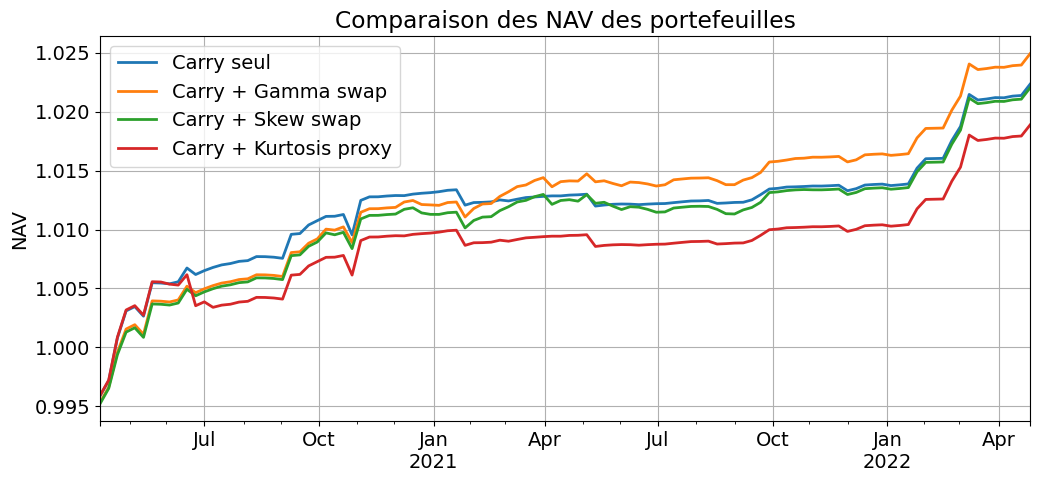

In [48]:
portfolio_nav = (1 + component_returns[
    ["carry_only", "carry_plus_gamma", "carry_plus_skew", "carry_plus_kurtosis"]
]).cumprod()

portfolio_nav.head()

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_nav["carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)
portfolio_nav["carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis proxy", lw=2)

ax.set_title("Comparaison des NAV des portefeuilles")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()

### Analyse des NAV

Le graphique compare l’évolution de la valeur liquidative (NAV) de quatre portefeuilles :

- Carry seul
- Carry + Gamma swap
- Carry + Skew swap
- Carry + Kurtosis

L’observation principale est que le portefeuille **carry + gamma swap** obtient la meilleure performance globale sur la période étudiée.

Le portefeuille **carry + skew swap** a sensiblement la même performance par rapport au carry seul. 

Le portefeuille **carry + kurtosis** présente quant à lui une performance légèrement inférieure aux autres stratégies. Dans cette implémentation, l'exposition au kurtosis ne semble donc pas améliorer le rendement moyen du portefeuille.

Une explication possible est que la variation du kurtosis réalisé est plus instable et moins persistante que les composantes de volatilité capturées par les gamma et skew swaps. Le proxy utilisé ici peut donc introduire davantage de variabilité dans les rendements.

### Comparaison des drawdowns des portefeuilles

L'analyse des drawdowns permet d'évaluer si l'ajout d'un overlay de swaps améliore la résistance du portefeuille de carry pendant les phases de baisse.

Cette lecture complète la comparaison des NAV : une stratégie peut en effet afficher une performance cumulée proche du carry seul, tout en modifiant sensiblement la profondeur ou la persistance des drawdowns. L'objectif est donc de déterminer si les overlays gamma et skew apportent une protection partielle dans les périodes de stress, ou s'ils ajoutent au contraire une source supplémentaire de risque.

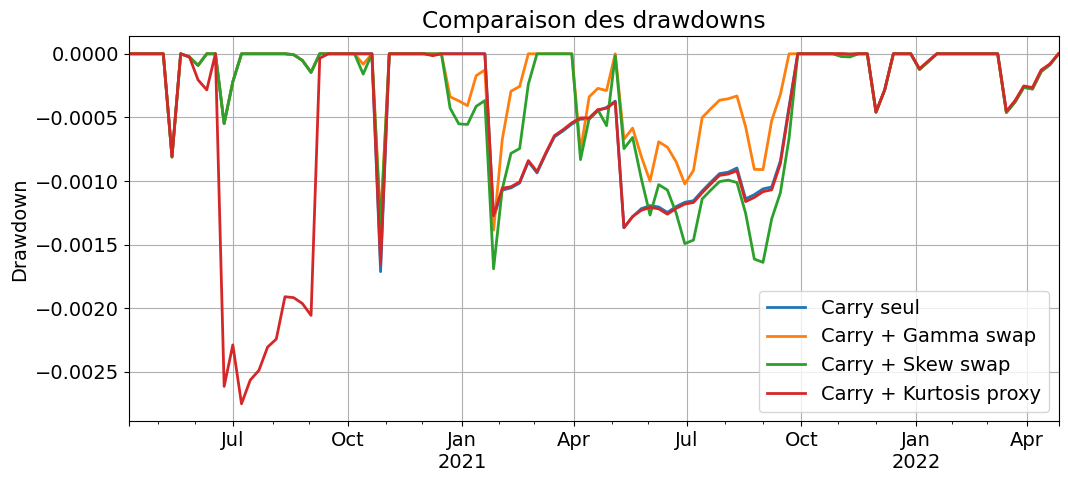

In [49]:
portfolio_drawdowns = portfolio_nav.apply(compute_drawdown)

fig, ax = plt.subplots(figsize=(12, 5))

portfolio_drawdowns["carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_drawdowns["carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_drawdowns["carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)
portfolio_drawdowns["carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis proxy", lw=2)

ax.set_title("Comparaison des drawdowns")
ax.set_ylabel("Drawdown")
ax.grid(True)
ax.legend()

plt.show()

### Analyse des drawdowns

La comparaison des drawdowns montre que l'ajout d'un overlay de swaps modifie légèrement le profil de risque du portefeuille de carry.

L'overlay gamma semble atténuer certains épisodes de drawdown, en particulier durant les phases de tension du marché. Cette propriété est cohérente avec l'exposition du gamma swap aux variations de volatilité, qui peuvent partiellement compenser les pertes du carry lorsque la volatilité augmente.

L'overlay skew produit un comportement plus proche du carry seul. Cette observation est cohérente avec les sections précédentes du projet, qui ont montré que les portefeuilles variance, gamma et skew restent fortement corrélés. L'exposition au troisième moment implicite reste donc relativement limitée dans ce cadre empirique.

Le portefeuille **carry + kurtosis** présente des drawdowns plus irréguliers et parfois plus marqués. Cela suggère que l'exposition au kurtosis réalisée ne joue pas ici un rôle stabilisateur comparable à celui des overlays gamma ou skew.

Dans l'ensemble, l'ajout de swaps sous forme d'overlay ne transforme pas radicalement la dynamique du portefeuille, mais peut légèrement améliorer son comportement pendant certaines phases de stress.

### Comparaison des performances des portefeuilles

On compare enfin les performances globales des différents portefeuilles construits à partir de la stratégie de carry et de ses overlays. Les métriques utilisées sont les mêmes que dans les sections précédentes : NAV finale, ratio de Sharpe, drawdown maximum et ratio de Calmar.

Cette synthèse permet d'évaluer si l'ajout d'une exposition aux swaps améliore le couple rendement-risque de la stratégie de carry. En particulier, on cherche à déterminer si les overlays gamma, skew ou kurtosis contribuent à stabiliser la performance ou à réduire la profondeur des drawdowns, tout en conservant une performance globale comparable au carry seul.

In [50]:
def compute_perf_from_nav(nav_series):
    rets = nav_series.pct_change().dropna()
    return {
        "Final NAV": nav_series.iloc[-1],
        "Sharpe": sharpe_ratio(rets),
        "Max Drawdown (%)": 100 * max_drawdown(rets),
        "Calmar": calmar_ratio(rets),
        "Mean daily return": rets.mean(),
        "Daily vol": rets.std(),
    }

portfolio_perf_df = pd.DataFrame({
    "Carry seul": compute_perf_from_nav(portfolio_nav["carry_only"]),
    "Carry + Gamma": compute_perf_from_nav(portfolio_nav["carry_plus_gamma"]),
    "Carry + Skew": compute_perf_from_nav(portfolio_nav["carry_plus_skew"]),
    "Carry + Kurtosis": compute_perf_from_nav(portfolio_nav["carry_plus_kurtosis"]),
}).T

portfolio_perf_df.round(4)

,Final NAV,Sharpe,Max Drawdown (%),Calmar,Mean daily return,Daily vol
Carry seul,1.0223,5.2256,-0.1712,36.1117,0.0002,0.0007
Carry + Gamma,1.0249,6.1727,-0.1386,49.8365,0.0003,0.0007
Carry + Skew,1.0220,5.5991,-0.1690,37.0817,0.0002,0.0007
Carry + Kurtosis,1.0189,4.2720,-0.2751,19.5420,0.0002,0.0008


### Analyse des performances des portefeuilles

Le tableau de performance confirme les observations faites sur les graphiques de NAV et de drawdown.

Le portefeuille **carry + gamma swap** présente la meilleure performance globale. Il obtient la NAV finale la plus élevée ainsi que le **meilleur ratio de Sharpe**, tout en réduisant légèrement le maximum drawdown par rapport à la stratégie de carry seule. Cela suggère que l'exposition au gamma apporte un gain de diversification et améliore le profil rendement-risque du portefeuille.

Le portefeuille **carry + skew swap** montre également une légère amélioration du ratio de Sharpe par rapport au carry seul, mais l'effet reste modéré. Cette proximité de performance est cohérente avec la **forte corrélation observée entre les stratégies gamma et skew**, qui capturent en grande partie des dynamiques similaires de la volatilité implicite.

À l'inverse, le portefeuille **carry + kurtosis** présente une performance plus faible. Sa NAV finale est inférieure à celle des autres stratégies et son maximum drawdown est plus important. Dans cette implémentation, l'ajout du proxy de kurtosis ne semble donc pas améliorer le profil rendement-risque du portefeuille.

Une explication possible est que la variation du quatrième moment réalisé est plus instable et moins persistante que les expositions capturées par les gamma et skew swaps. Le proxy de kurtosis utilisé ici peut donc introduire davantage de variabilité dans les rendements sans fournir une protection efficace contre les phases de stress du carry.

### Corrélation entre les composantes du portefeuille

Avant de combiner les différentes stratégies, il est utile d'examiner la corrélation entre leurs rendements. Une corrélation faible ou modérée entre les composantes suggère un potentiel de diversification lorsque ces expositions sont combinées dans un même portefeuille.

On calcule donc ici la matrice de corrélation entre les rendements du carry et ceux des overlays gamma, skew et kurtosis (après normalisation de leur volatilité).

In [51]:
corr_components_df = component_returns[
    ["carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"]
].corr()

corr_components_df.round(3)

,carry,gamma_scaled,skew_scaled,kurtosis_scaled
carry,1.000,-0.146,-0.126,0.056
gamma_scaled,-0.146,1.000,0.984,0.015
skew_scaled,-0.126,0.984,1.000,-0.004
kurtosis_scaled,0.056,0.015,-0.004,1.000


### Analyse des corrélations entre les composantes

La matrice de corrélation permet d'évaluer le potentiel de diversification des différentes sleeves du portefeuille.

On observe tout d'abord que la stratégie de **carry** présente une corrélation légèrement négative avec les overlays **gamma** et **skew**. Cette propriété est cohérente avec l'intuition économique : lors des épisodes de hausse de volatilité ou de mouvements brusques du marché, les stratégies de vente d'options (carry) tendent à souffrir tandis que les expositions gamma peuvent bénéficier de ces conditions.

Les stratégies **gamma et skew** présentent en revanche une corrélation extrêmement élevée (≈ 0.98). Cela indique qu'elles capturent des dynamiques très similaires de la volatilité implicite. Dans ce contexte, l'ajout simultané des deux overlays n'apporte qu'un gain de diversification limité.

Le **proxy de kurtosis** présente une corrélation très faible avec les autres composantes du portefeuille. Cette faible relation statistique suggère qu'il capture une dimension différente de la distribution des rendements, mais également que son comportement est plus instable et moins directement lié aux dynamiques de volatilité exploitées par les gamma et skew swaps.

### Analyse des performances en périodes de stress du carry

Pour évaluer le rôle potentiel des overlays dans les phases défavorables au carry, on identifie les **jours de stress du carry**, définis ici comme les 10 % des observations où le rendement du carry est le plus faible.

On examine ensuite, sur ces journées spécifiques :

- le **rendement moyen** des différentes composantes ;
- le **rendement médian** ;
- la **corrélation avec le carry**.

Cette analyse permet de vérifier si les overlays gamma, skew ou kurtosis ont tendance à compenser les pertes du carry durant ses phases les plus difficiles, ce qui constituerait un mécanisme potentiel de stabilisation du portefeuille.

In [52]:
stress_threshold = component_returns["carry"].quantile(0.10)
stress_mask = component_returns["carry"] <= stress_threshold

stress_summary = pd.DataFrame({
    "Mean return in carry stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].mean(),
    "Median return in carry stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].median(),
    "Correlation with carry in stress days": component_returns.loc[stress_mask, [
        "carry", "gamma_scaled", "skew_scaled", "kurtosis_scaled"
    ]].corr()["carry"],
})

stress_summary.round(6)

,Mean return in carry stress days,Median return in carry stress days,Correlation with carry in stress days
carry,-0.000988,-0.000549,1.000000
gamma_scaled,0.000071,0.000000,0.524900
skew_scaled,-0.000030,0.000000,0.632903
kurtosis_scaled,-0.000697,0.000021,-0.149496


### Analyse des overlays en période de stress du carry

L'analyse conditionnée aux pires journées de la stratégie de carry permet d'évaluer si les différents overlays jouent un rôle de couverture lors des épisodes défavorables.

Comme attendu, le rendement moyen du **carry** est fortement négatif durant ces périodes. Les résultats montrent que l'overlay **gamma** génère en moyenne un rendement positif lors des journées de stress du carry. Cela suggère que l'exposition gamma peut agir comme une **couverture partielle**, bénéficiant des mouvements plus marqués du marché qui pénalisent généralement les stratégies vendeuses d'options.

L'overlay **skew** présente un comportement plus neutre. Son rendement moyen est légèrement négatif et sa corrélation avec le carry reste relativement élevée. Cela indique que, dans cette implémentation, le skew swap apporte une diversification limitée dans les pires phases de la stratégie de carry.

Le **proxy de kurtosis** présente quant à lui une corrélation négative avec le carry durant les périodes de stress, ce qui suggère une dynamique différente des autres overlays. Toutefois, son rendement moyen reste négatif, ce qui indique qu'il ne fournit pas de protection efficace dans ces épisodes.

Dans l'ensemble, ces résultats confirment que **l'overlay gamma est celui qui offre la meilleure capacité de stabilisation du portefeuille de carry**, tandis que les overlays skew et kurtosis apportent une diversification plus limitée dans les phases de stress.

### Comportement des portefeuilles en période de stress du carry

Après avoir examiné les composantes individuelles, on analyse maintenant le comportement des **portefeuilles complets** durant les journées de stress du carry. Ces journées correspondent aux 10 % des observations où la stratégie de carry enregistre ses rendements les plus faibles.

On compare ici les **rendements moyens et médians** des quatre portefeuilles :

- carry seul ;
- carry avec overlay gamma ;
- carry avec overlay skew ;
- carry avec overlay kurtosis.

Cette analyse permet de vérifier si l'ajout des overlays contribue effectivement à **amortir les pertes du portefeuille** lorsque la stratégie de carry traverse ses phases les plus difficiles.

In [53]:
portfolio_stress_summary = pd.DataFrame({
    "Mean return in carry stress days": component_returns.loc[stress_mask, [
        "carry_only", "carry_plus_gamma", "carry_plus_skew", "carry_plus_kurtosis"
    ]].mean(),
    "Median return in carry stress days": component_returns.loc[stress_mask, [
        "carry_only", "carry_plus_gamma", "carry_plus_skew", "carry_plus_kurtosis"
    ]].median(),
})

portfolio_stress_summary.round(6)

,Mean return in carry stress days,Median return in carry stress days
carry_only,-0.000988,-0.000549
carry_plus_gamma,-0.000970,-0.000549
carry_plus_skew,-0.000995,-0.000549
carry_plus_kurtosis,-0.001162,-0.000808


### Analyse des portefeuilles en période de stress du carry

L'analyse des journées de stress du carry permet d'évaluer si les overlays améliorent le comportement du portefeuille lorsque la stratégie de vente d'options traverse ses phases les plus difficiles.

Comme attendu, le portefeuille **carry seul** présente des rendements moyens fortement négatifs durant ces périodes. L'ajout de l'overlay **gamma** permet d'atténuer légèrement ces pertes : le rendement moyen devient moins négatif que celui du carry seul. Cela confirme que l'exposition au gamma peut jouer un rôle de **couverture partielle** lorsque les mouvements de marché deviennent plus importants.

L'overlay **skew** ne montre pas la même propriété. Le rendement moyen reste légèrement inférieur à celui du carry seul, ce qui suggère que cette exposition n'apporte pas de protection significative dans les pires phases du carry.

Le portefeuille **carry + kurtosis** présente les performances les plus faibles durant les périodes de stress. Son rendement moyen est plus négatif et la médiane des rendements est également plus faible. Dans cette implémentation, l'ajout du proxy de kurtosis ne semble donc pas améliorer la robustesse du portefeuille face aux épisodes défavorables.

Dans l'ensemble, ces résultats suggèrent que **l'overlay gamma est celui qui apporte l'amélioration la plus claire du comportement du portefeuille en période de stress**, tandis que les overlays skew et kurtosis contribuent peu à la stabilisation du carry dans cette configuration empirique.

### Zoom sur la crise de 2020

Afin d'illustrer plus concrètement le comportement des portefeuilles en période de stress, on examine la trajectoire de NAV durant la phase de forte turbulence du marché au premier semestre 2020.

Cette période constitue un test naturel pour les stratégies de carry sur options, car les mouvements violents du sous-jacent et l'augmentation de la volatilité implicite sont généralement défavorables aux positions vendeuses d'options.

La comparaison des différents portefeuilles permet d'évaluer si l'ajout d'overlays liés aux facteurs de volatilité (gamma, skew et kurtosis) modifie le comportement du carry dans ce contexte extrême. On cherche notamment à déterminer si ces expositions contribuent à atténuer les pertes du portefeuille ou à stabiliser sa trajectoire pendant la crise.

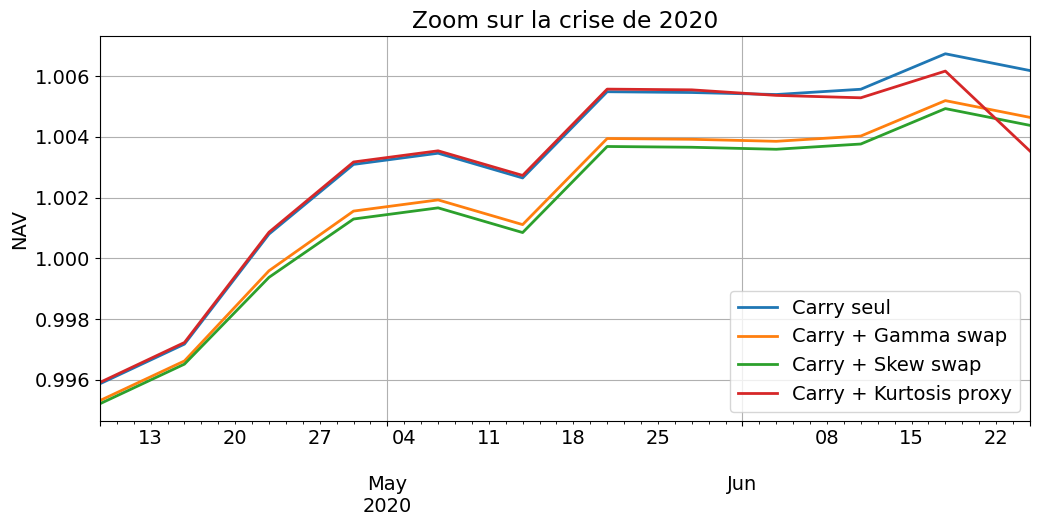

In [54]:
fig, ax = plt.subplots(figsize=(12, 5))

portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_only"].plot(ax=ax, label="Carry seul", lw=2)
portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_plus_gamma"].plot(ax=ax, label="Carry + Gamma swap", lw=2)
portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_plus_skew"].plot(ax=ax, label="Carry + Skew swap", lw=2)
portfolio_nav.loc["2020-02-01":"2020-06-30", "carry_plus_kurtosis"].plot(ax=ax, label="Carry + Kurtosis proxy", lw=2)

ax.set_title("Zoom sur la crise de 2020")
ax.set_ylabel("NAV")
ax.grid(True)
ax.legend()

plt.show()


### Analyse de la crise de 2020

Le zoom sur la période de la crise du COVID-19 permet d’observer le comportement des différentes stratégies pendant un épisode de stress extrême.

Durant cette période :

- les portefeuilles **carry + gamma** et **carry + skew** suivent une trajectoire similaire et semblent légèrement bénéficier de l’augmentation de la volatilité réalisée ;
- le portefeuille **carry + kurtosis** reste globalement proche du comportement du carry seul.

Cela suggère que le proxy de kurtosis utilisé dans cette analyse ne capture pas aussi efficacement la dynamique des épisodes de volatilité extrême que les expositions gamma et skew construites à partir des options.

## Conclusion

Ce projet avait pour objectif d'étudier empiriquement l'intérêt des **moment swaps** comme sources potentielles de diversification ou de couverture dans une stratégie de trading de volatilité.

Dans un premier temps, nous avons construit une **réplication discrète d'un gamma swap** et proposé deux approches pour le **skew swap** : une construction empirique par combinaison de variance et gamma swaps, puis une réplication directe basée sur une pondération en \(1/K^3\). Ces implémentations s'appuient sur la réplication statique par strip d'options OTM, dans l'esprit des travaux de Lee (2006) et de la littérature sur les moment swaps.

Nous avons ensuite comparé ces stratégies aux moments réalisés de la distribution des rendements afin de vérifier leur interprétation économique. Les résultats montrent que les expositions gamma et skew capturent des dynamiques très proches de la volatilité implicite, avec une corrélation extrêmement élevée entre elles, tandis que les proxies de moments d'ordre supérieur (notamment le kurtosis réalisé) présentent un comportement plus instable.

Dans une seconde étape, ces expositions ont été utilisées comme **overlays dans une stratégie de carry** basée sur un short strangle delta-hedgé sur SPY. Les différentes composantes ont été normalisées par leur volatilité réalisée afin de comparer des expositions économiquement comparables.

Les résultats empiriques montrent que :

- l'overlay **gamma** améliore le profil rendement-risque du carry, avec une NAV finale plus élevée, un ratio de Sharpe supérieur et des drawdowns légèrement réduits ;
- l'overlay **skew** apporte une amélioration plus modérée, ce qui est cohérent avec sa forte corrélation avec le gamma swap ;
- le **proxy de kurtosis** ne semble pas améliorer la performance du portefeuille dans cette implémentation et introduit davantage de variabilité dans les rendements.

L'analyse des corrélations confirme que les stratégies gamma et skew capturent des facteurs très proches de la dynamique de volatilité, tandis que le kurtosis présente une relation plus faible mais également plus instable avec les autres composantes. Enfin, l'analyse conditionnée aux périodes de stress du carry montre que l'overlay gamma peut jouer un rôle de **couverture partielle** lorsque la stratégie de vente d'options subit ses pertes les plus importantes.

Dans l'ensemble, ces résultats suggèrent que les **moment swaps peuvent constituer des outils utiles pour améliorer le profil de risque d'une stratégie de carry**, en particulier dans le cas du gamma swap. Leur intérêt semble toutefois dépendre fortement de la nature du facteur de volatilité capturé et de la stabilité empirique de l'exposition utilisée.